In [ ]:
# 나눔폰트 최신버전 zip 다운로드 (2020년 버전)
!wget -q https://github.com/naver/nanumfont/releases/download/VER20201130/NanumFont_TTF_ALL.zip

# 압축 해제 (다운받은 파일이 있는지 확인 후 진행)
!unzip -o NanumFont_TTF_ALL.zip -d /usr/share/fonts/truetype/nanum

# 폰트 캐시 재생성
!fc-cache -fv

# 설치된 나눔폰트 리스트 확인
import matplotlib.font_manager as fm
nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print("설치된 나눔 폰트:", nanum_fonts)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 파일 업로드
from google.colab import files
uploaded = files.upload()

# 데이터 로드
df = pd.read_csv('data5000.csv')

# 예시: '조회수' 예측, 결측치/문자열 처리
df = df.dropna(subset=['조회수'])
y = df['조회수']
X = df.drop(['조회수', 'video_id', '영상제목_x', '채널ID', '채널명', '썸네일URL_x', '게시일_dt', '업로드_시각', '추출된_텍스트', '키워드', '토픽키워드'], axis=1, errors='ignore')

# 범주형 인코딩 (간단 예시)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Saving data5000.csv to data5000.csv


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# 그리드서치
grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 랜덤서치 (시간 단축 필요시)
# random_search = RandomizedSearchCV(RandomForestRegressor(), param_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
# random_search.fit(X_train, y_train)

print("Grid Best Params:", grid_search.best_params_)
print("Grid Best Score:", -grid_search.best_score_)


Grid Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Grid Best Score: 7117043973.359427


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )
    # Pruning 적용
    score = cross_val_score(rf, X_train, y_train, cv=3, scoring='neg_mean_squared_error')
    trial.report(-score.mean(), step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()
    return -score.mean()

pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction='minimize', pruner=pruner)
study.optimize(objective, n_trials=30)

print("Optuna Best Params:", study.best_params)
print("Optuna Best Score:", study.best_value)


[I 2025-06-09 01:23:20,945] A new study created in memory with name: no-name-a81359bf-882d-4256-960c-2efe3890e250
[I 2025-06-09 01:23:25,335] Trial 0 finished with value: 8356912276.377033 and parameters: {'n_estimators': 192, 'max_depth': 28, 'min_samples_split': 8}. Best is trial 0 with value: 8356912276.377033.
[I 2025-06-09 01:23:27,536] Trial 1 finished with value: 8250326561.615174 and parameters: {'n_estimators': 97, 'max_depth': 26, 'min_samples_split': 12}. Best is trial 1 with value: 8250326561.615174.
[I 2025-06-09 01:23:34,093] Trial 2 finished with value: 8471835497.95836 and parameters: {'n_estimators': 273, 'max_depth': 14, 'min_samples_split': 17}. Best is trial 1 with value: 8250326561.615174.
[I 2025-06-09 01:23:35,190] Trial 3 finished with value: 7629807395.972615 and parameters: {'n_estimators': 70, 'max_depth': 7, 'min_samples_split': 3}. Best is trial 3 with value: 7629807395.972615.
[I 2025-06-09 01:23:37,648] Trial 4 finished with value: 7723945865.133817 and p

Optuna Best Params: {'n_estimators': 136, 'max_depth': 25, 'min_samples_split': 2}
Optuna Best Score: 7378932299.488216


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

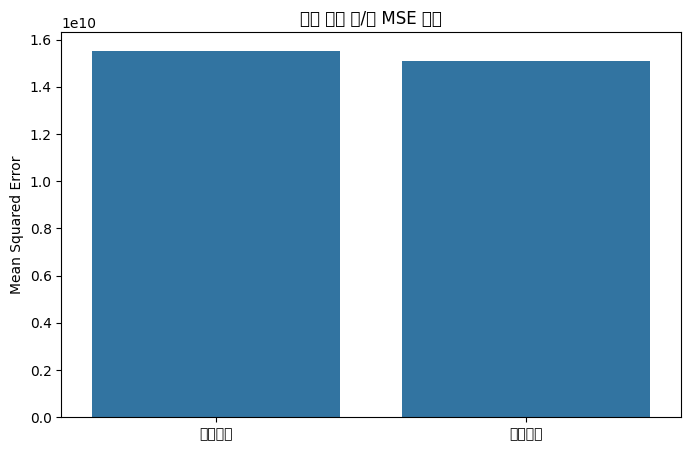

기본 모델 MSE: 15535154574.16
튜닝 모델 MSE: 15086464077.75


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# 기본 모델
rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
mse_base = mean_squared_error(y_test, y_pred_base)

# 최적화 모델
rf_opt = RandomForestRegressor(**study.best_params, random_state=42)
rf_opt.fit(X_train, y_train)
y_pred_opt = rf_opt.predict(X_test)
mse_opt = mean_squared_error(y_test, y_pred_opt)

# 비교 시각화
plt.figure(figsize=(8,5))
sns.barplot(x=['기본모델', '튜닝모델'], y=[mse_base, mse_opt])
plt.title('모델 개선 전/후 MSE 비교')
plt.ylabel('Mean Squared Error')
plt.show()

print(f"기본 모델 MSE: {mse_base:.2f}")
print(f"튜닝 모델 MSE: {mse_opt:.2f}")

optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()


Saving final_data_0609.csv to final_data_0609 (2).csv


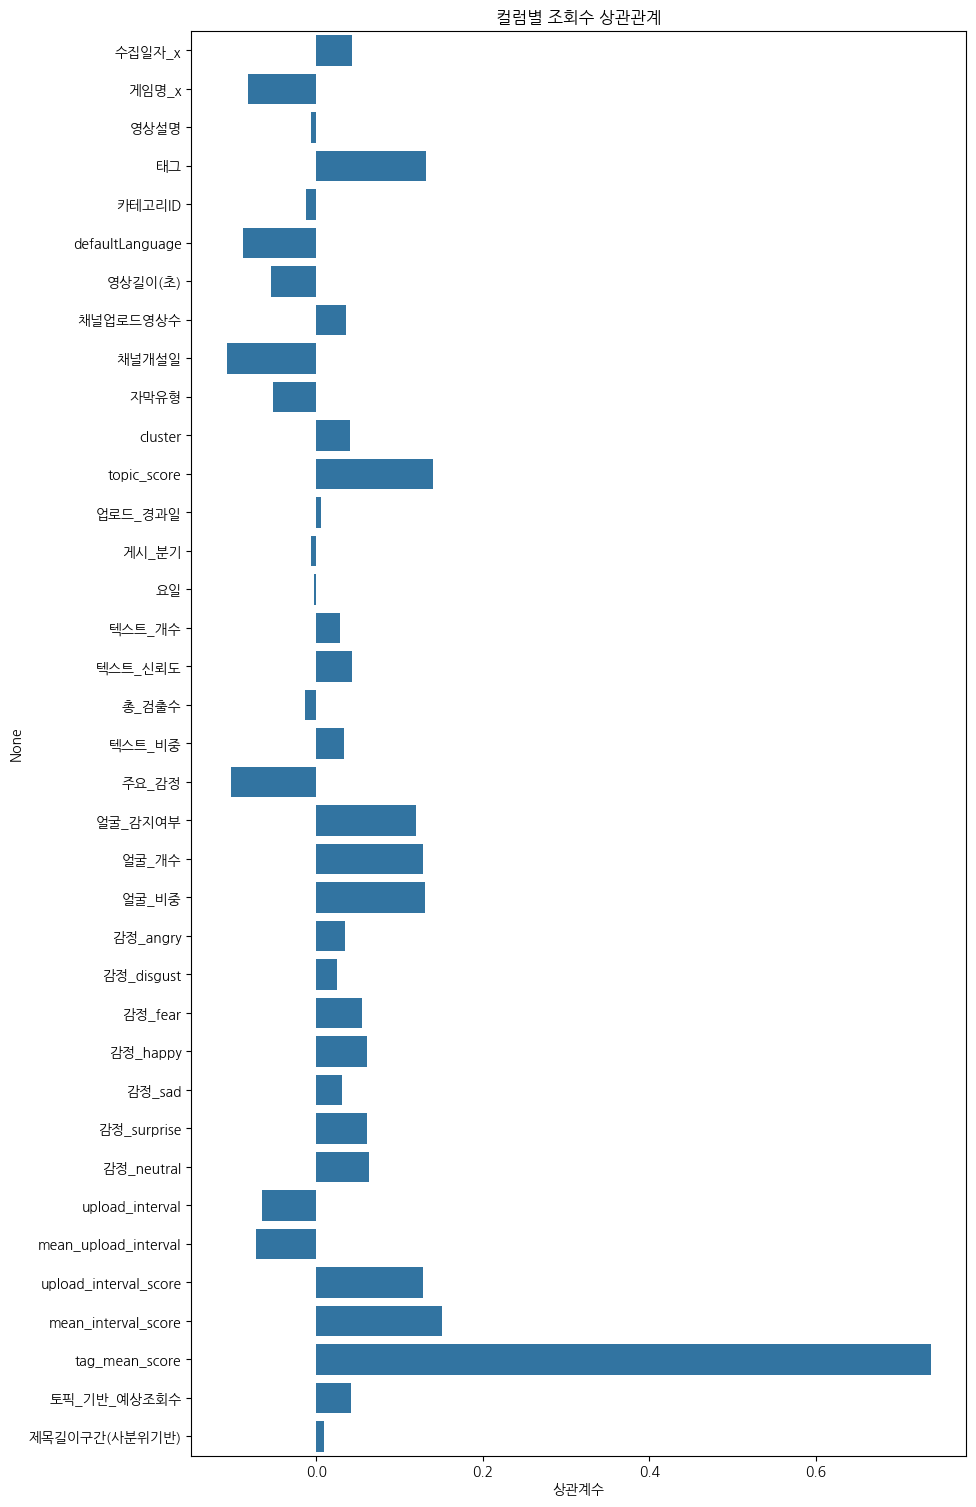

[I 2025-06-09 11:23:20,828] A new study created in memory with name: no-name-b68791aa-ed2f-4775-98f5-3370e28f27f8
[I 2025-06-09 11:24:01,277] Trial 0 finished with value: 65103.00330438549 and parameters: {'n_estimators': 102, 'max_depth': 21, 'min_samples_split': 3}. Best is trial 0 with value: 65103.00330438549.
[I 2025-06-09 11:25:10,311] Trial 1 finished with value: 66067.73874415975 and parameters: {'n_estimators': 276, 'max_depth': 12, 'min_samples_split': 6}. Best is trial 0 with value: 65103.00330438549.
[I 2025-06-09 11:25:56,774] Trial 2 finished with value: 64911.83067269436 and parameters: {'n_estimators': 117, 'max_depth': 25, 'min_samples_split': 20}. Best is trial 2 with value: 64911.83067269436.
[I 2025-06-09 11:26:26,976] Trial 3 finished with value: 65790.66927407113 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 6}. Best is trial 2 with value: 64911.83067269436.
[I 2025-06-09 11:26:52,925] Trial 4 finished with value: 65831.1817357702 and

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4806
[LightGBM] [Info] Number of data points in the train set: 23282, number of used features: 37
[LightGBM] [Info] Start training from score 38405.321106
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2025-06-09 11:48:10,094] Trial 0 finished with value: 61411.0027851478 and parameters: {'n_estimators': 207, 'max_depth': 10, 'learning_rate': 0.26601998498857693, 'subsample': 0.7492528197052138, 'colsample_bytree': 0.9965584006294679}. Best is trial 0 with value: 61411.0027851478.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.170503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4806
[LightGBM] [Info] Number of data points in the train set: 23282, number of used features: 37
[LightGBM] [Info] Start training from score 38405.321106


[I 2025-06-09 11:48:13,360] Trial 1 finished with value: 62952.30943814846 and parameters: {'n_estimators': 242, 'max_depth': 12, 'learning_rate': 0.030448759822769206, 'subsample': 0.7501844294072864, 'colsample_bytree': 0.9195204512744417}. Best is trial 0 with value: 61411.0027851478.


...

[I 2025-06-09 11:48:33,920] Trial 18 finished with value: 61471.691828074094 and parameters: {'n_estimators': 142, 'max_depth': 7, 'learning_rate': 0.22984568909471306, 'subsample': 0.5741049858643366, 'colsample_bytree': 0.6470528181886889}. Best is trial 11 with value: 60125.55855021981.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4806
[LightGBM] [Info] Number of data points in the train set: 23282, number of used features: 37
[LightGBM] [Info] Start training from score 38405.321106


[I 2025-06-09 11:48:34,571] Trial 19 finished with value: 63734.27336045488 and parameters: {'n_estimators': 96, 'max_depth': 11, 'learning_rate': 0.0556001107923557, 'subsample': 0.540936669964477, 'colsample_bytree': 0.5707269373454905}. Best is trial 11 with value: 60125.55855021981.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012718 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4806
[LightGBM] [Info] Number of data points in the train set: 23282, number of used features: 37
[LightGBM] [Info] Start training from score 38405.321106
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2025-06-09 11:48:35,992] A new study created in memory with name: no-name-c5cb9019-ae88-4590-8726-40b80926cd4c
[I 2025-06-09 11:48:42,145] Trial 0 finished with value: 62925.80506115951 and parameters: {'iterations': 264, 'depth': 7, 'learning_rate': 0.28012212111862}. Best is trial 0 with value: 62925.80506115951.
[I 2025-06-09 11:48:48,955] Trial 1 finished with value: 62476.89259964483 and parameters: {'iterations': 155, 'depth': 9, 'learning_rate': 0.17066808662690564}. Best is trial 1 with value: 62476.89259964483.
[I 2025-06-09 11:48:55,388] Trial 2 finished with value: 65083.91482317788 and parameters: {'iterations': 59, 'depth': 10, 'learning_rate': 0.2580798551145792}. Best is trial 1 with value: 62476.89259964483.
[I 2025-06-09 11:49:01,701] Trial 3 finished with value: 63738.50772479977 and parameters: {'iterations': 242, 'depth': 8, 'learning_rate': 0.04403287682416239}. Best is trial 1 with value: 62476.89259964483.
[I 2025-06-09 11:49:10,102] Trial 4 finished with valu

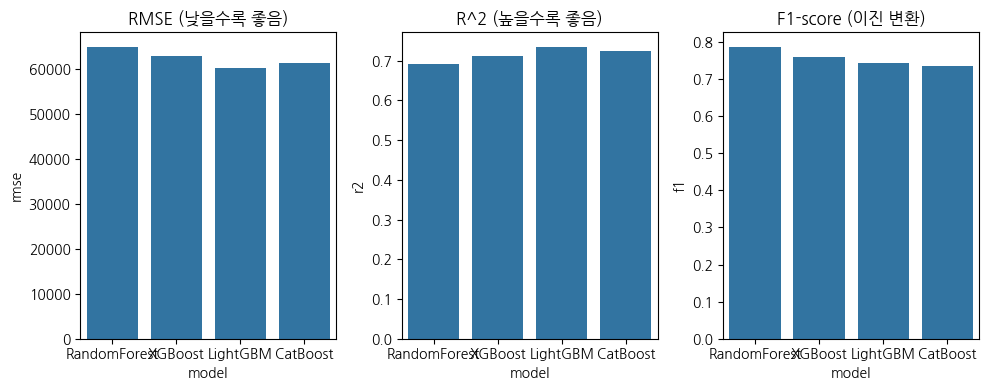

          model          rmse        r2        f1
0  RandomForest  64797.254976  0.691430  0.786698
1       XGBoost  62721.710181  0.710881  0.759735
2      LightGBM  60125.558550  0.734320  0.742949
3      CatBoost  61293.983970  0.723894  0.735132

가장 성능 좋은 모델: LightGBM
최적 하이퍼파라미터: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 0.6216928906522318, 'importance_type': 'split', 'learning_rate': 0.10300392993774507, 'max_depth': 11, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 297, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.512497668931481, 'subsample_for_bin': 200000, 'subsample_freq': 0}


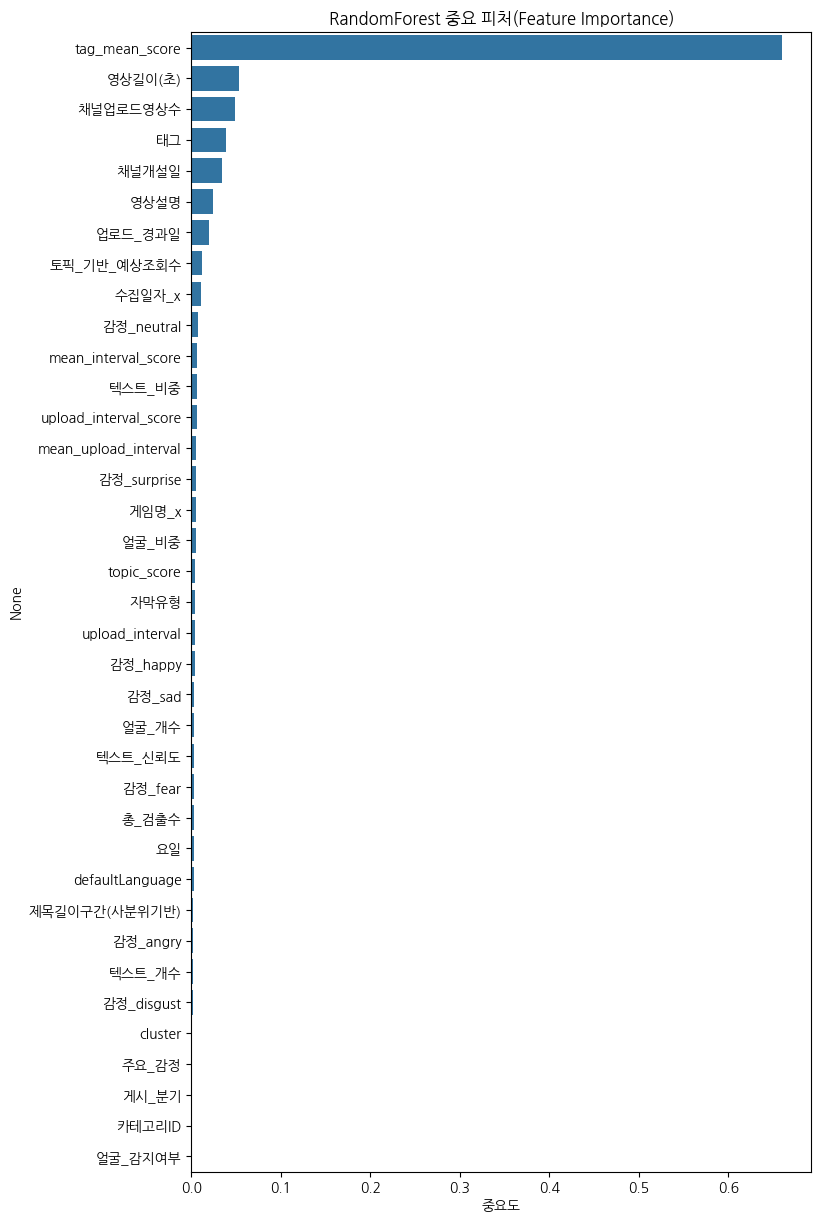

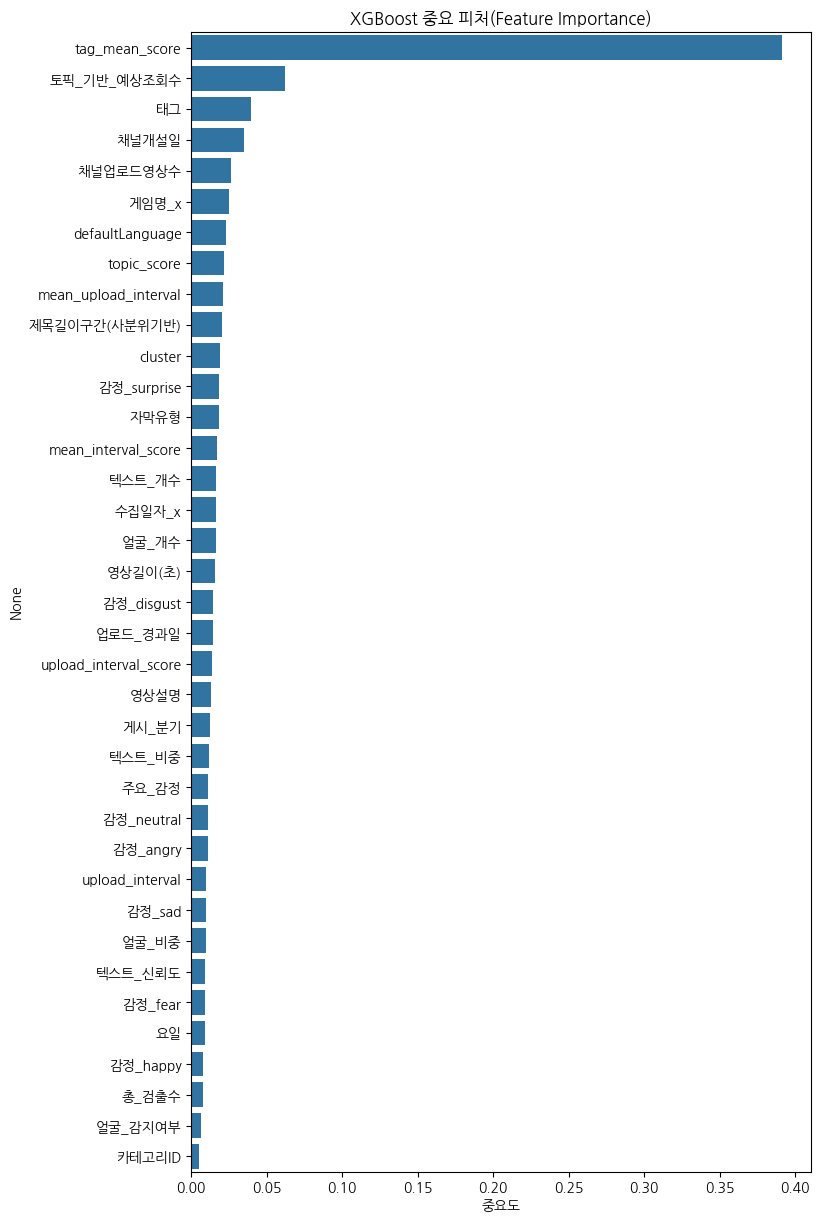

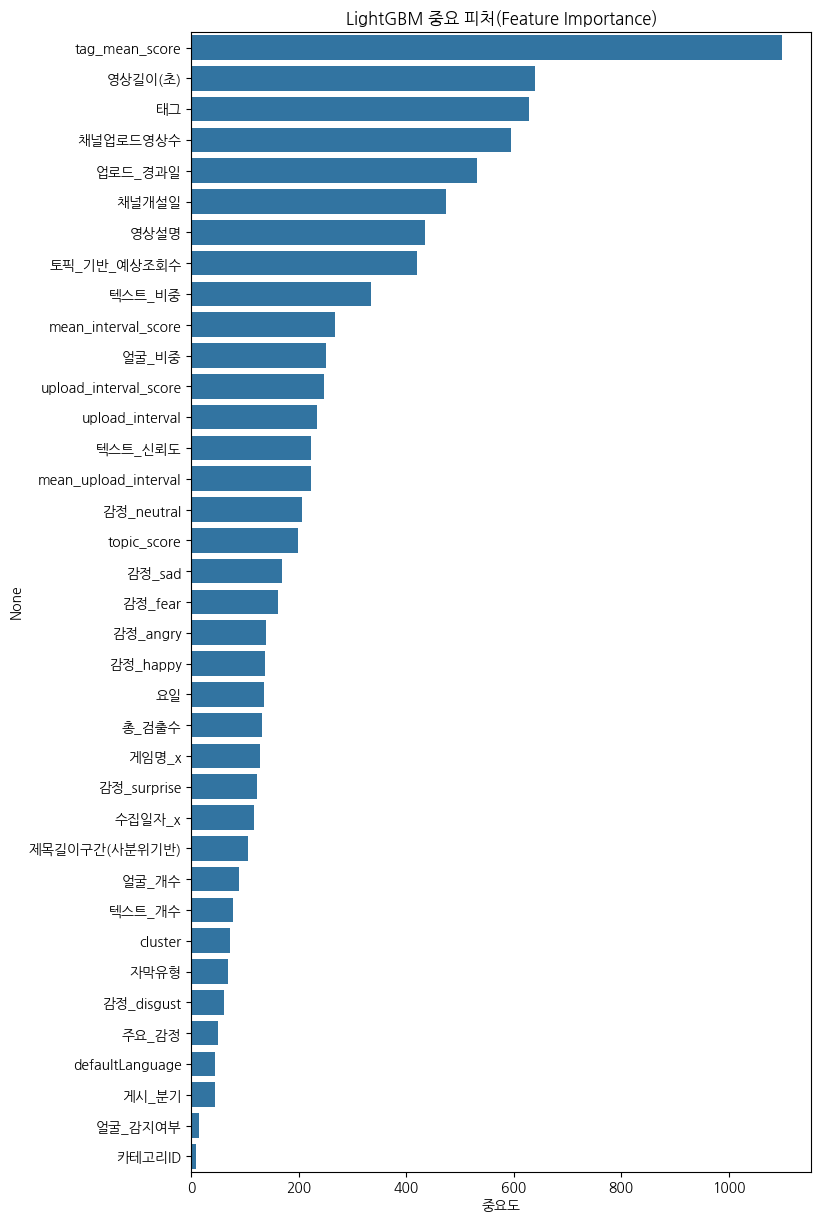

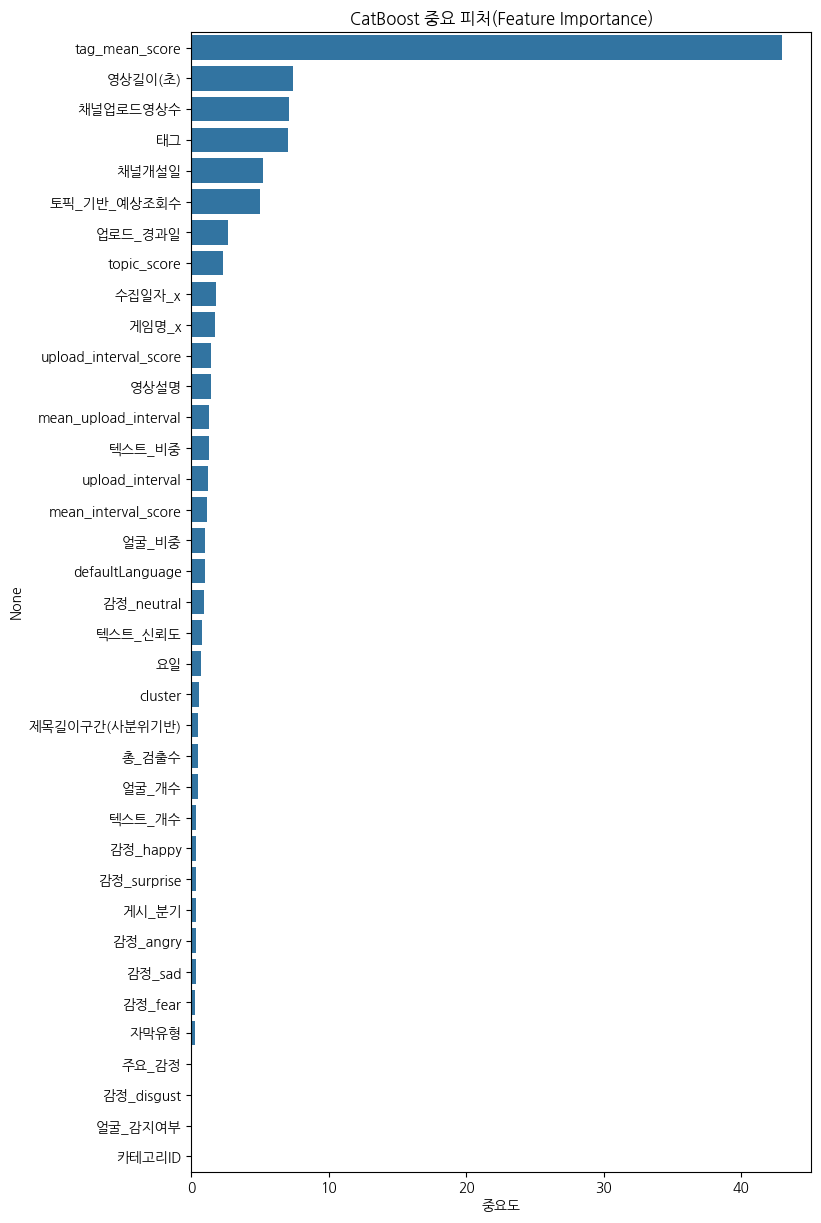

In [28]:
# 1. 한글 폰트 설치 및 적용 (코랩 전용)
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

plt.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. 라이브러리 설치 (필요시)
!pip install optuna xgboost lightgbm catboost scikit-learn pandas

# 3. 데이터 업로드 및 전처리
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.colab import files

uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)), encoding='utf-8')

drop_cols = ['video_id', '영상제목_x', '채널ID', '채널명', '썸네일URL_x', '게시일_dt', '업로드_시각', '추출된_텍스트', '키워드', '토픽키워드']
target = '조회수'
df = df.dropna(subset=[target])
X = df.drop([target]+drop_cols, axis=1, errors='ignore')
y = df[target]

# 범주형 인코딩
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 결측치 완전 제거 (중요!)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 컬럼별 조회수 상관관계 시각화
corrs = pd.concat([X, y], axis=1).corr()[target].drop(target)
plt.figure(figsize=(10, 0.5*len(corrs)))
sns.barplot(x=corrs.values, y=corrs.index, orient='h')
plt.title('컬럼별 조회수 상관관계')
plt.xlabel('상관계수')
plt.show()

# 5. 회귀 모델별 Optuna 하이퍼파라미터 튜닝 함수 정의
import optuna
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score, f1_score

def regression_objective(trial, model_name):
    if model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**params)
    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'n_jobs': -1
        }
        model = XGBRegressor(**params)
    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'n_jobs': -1
        }
        model = LGBMRegressor(**params)
    elif model_name == 'CatBoost':
        params = {
            'iterations': trial.suggest_int('iterations', 50, 300),
            'depth': trial.suggest_int('depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'random_seed': 42,
            'verbose': 0
        }
        model = CatBoostRegressor(**params)
    else:
        raise ValueError('지원하지 않는 모델')

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    return rmse

# 6. 각 모델별 Optuna 튜닝 및 결과 저장
model_names = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
best_models = {}
results = []

for model_name in model_names:
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: regression_objective(trial, model_name), n_trials=20)
    if model_name == 'RandomForest':
        model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
    elif model_name == 'XGBoost':
        model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
    elif model_name == 'LightGBM':
        model = LGBMRegressor(**study.best_params, random_state=42, n_jobs=-1)
    elif model_name == 'CatBoost':
        model = CatBoostRegressor(**study.best_params, random_seed=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    y_pred_bin = (preds > np.median(y_train)).astype(int)
    y_true_bin = (y_test > np.median(y_train)).astype(int)
    f1 = f1_score(y_true_bin, y_pred_bin)
    best_models[model_name] = model
    results.append({'model': model_name, 'rmse': rmse, 'r2': r2, 'f1': f1})

# 7. 모델별 성능 비교 시각화
results_df = pd.DataFrame(results)
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
sns.barplot(x='model', y='rmse', data=results_df)
plt.title('RMSE (낮을수록 좋음)')
plt.subplot(1,3,2)
sns.barplot(x='model', y='r2', data=results_df)
plt.title('R^2 (높을수록 좋음)')
plt.subplot(1,3,3)
sns.barplot(x='model', y='f1', data=results_df)
plt.title('F1-score (이진 변환)')
plt.tight_layout()
plt.show()

print(results_df)

# 8. 가장 성능 좋은 모델 및 하이퍼파라미터 출력
best_row = results_df.sort_values('rmse').iloc[0]
print(f"\n가장 성능 좋은 모델: {best_row['model']}")
print("최적 하이퍼파라미터:", best_models[best_row['model']].get_params())

# 9. 중요 피처 시각화 (Feature Importance)
for model_name in model_names:
    model = best_models[model_name]
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        plt.figure(figsize=(8, 0.4*len(X.columns)))
        sns.barplot(x=importances[indices], y=X.columns[indices])
        plt.title(f'{model_name} 중요 피처(Feature Importance)')
        plt.xlabel('중요도')
        plt.show()
    elif model_name == 'CatBoost':
        importances = model.get_feature_importance()
        indices = np.argsort(importances)[::-1]
        plt.figure(figsize=(8, 0.4*len(X.columns)))
        sns.barplot(x=np.array(importances)[indices], y=X.columns[indices])
        plt.title(f'{model_name} 중요 피처(Feature Importance)')
        plt.xlabel('중요도')
        plt.show()


데이터 shape: (29103, 47)
컬럼 목록: ['수집일자_x', '게임명_x', 'video_id', '영상제목_x', '영상설명', '채널ID', '채널명', '태그', '카테고리ID', 'defaultLanguage', '영상길이(초)', '채널업로드영상수', '채널개설일', '자막유형', 'cluster', 'topic_score', '게시일_dt', '업로드_시각', '업로드_경과일', '게시_분기', '요일', '조회수', '추출된_텍스트', '키워드', '텍스트_개수', '텍스트_신뢰도', '총_검출수', '텍스트_비중', '주요_감정', '얼굴_감지여부', '얼굴_개수', '얼굴_비중', '감정_angry', '감정_disgust', '감정_fear', '감정_happy', '감정_sad', '감정_surprise', '감정_neutral', 'upload_interval', 'mean_upload_interval', 'upload_interval_score', 'mean_interval_score', 'tag_mean_score', '토픽키워드', '토픽_기반_예상조회수', '제목길이구간(사분위기반)']


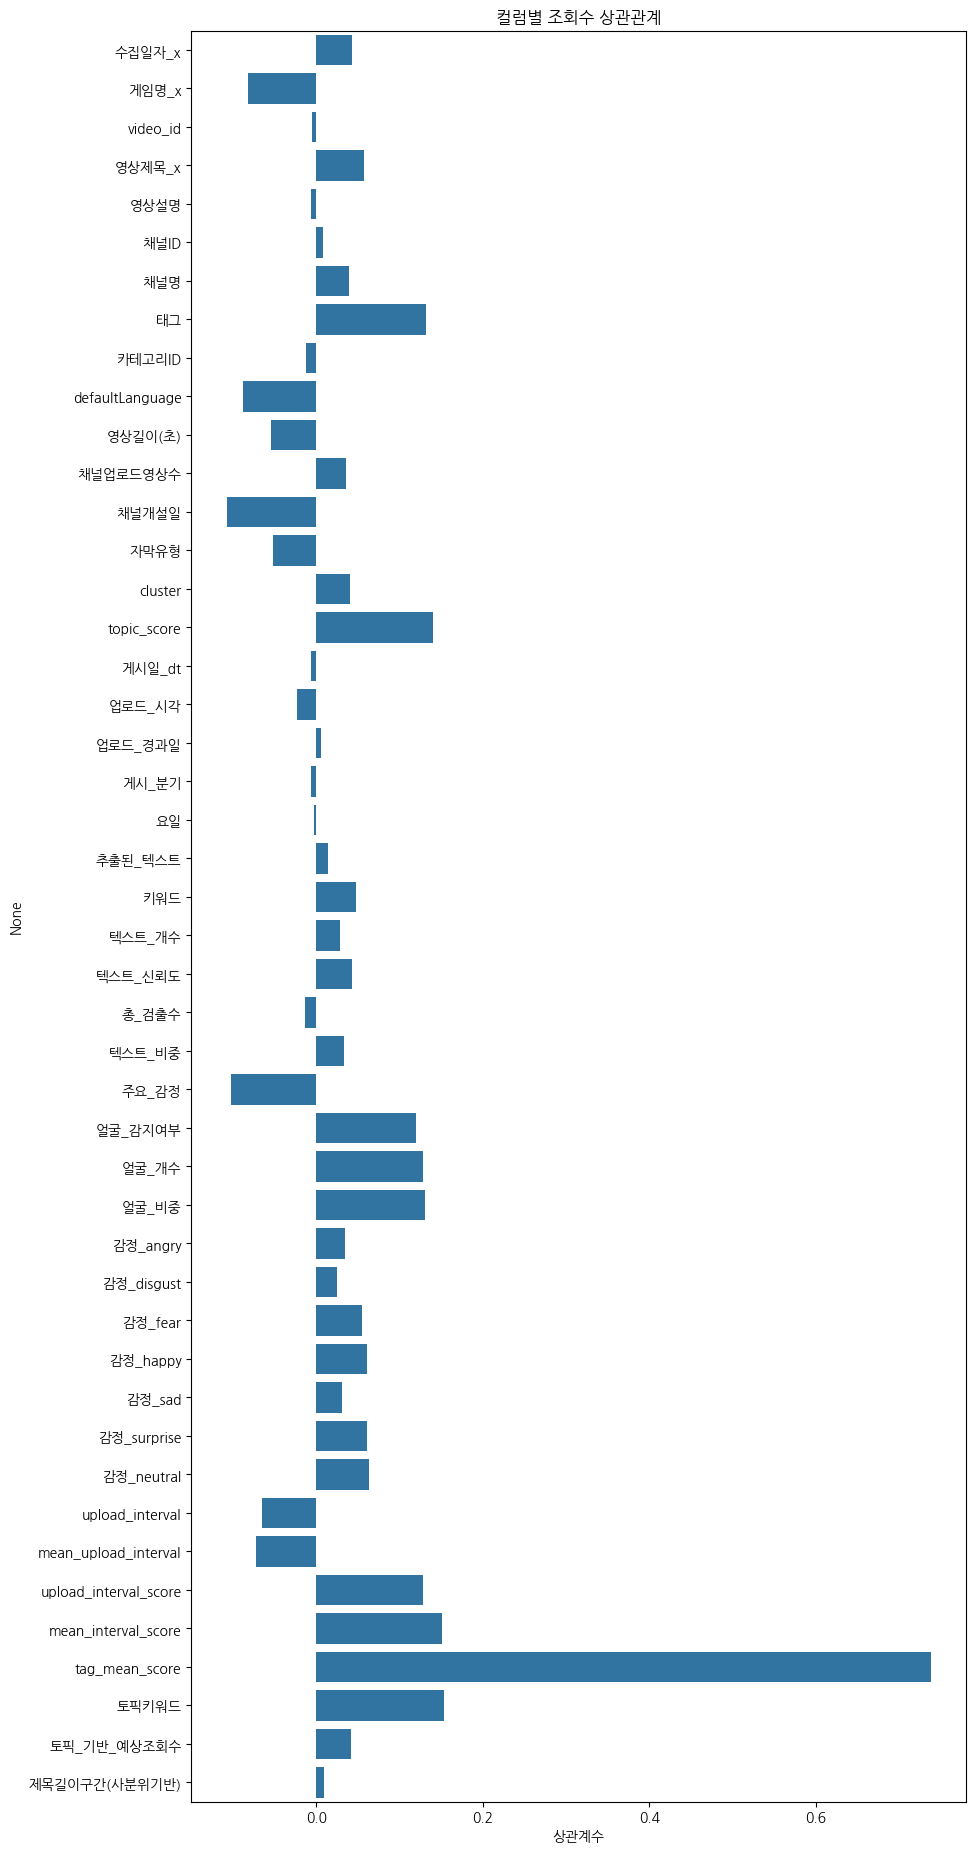

[I 2025-06-09 10:42:21,585] A new study created in memory with name: no-name-299908d7-0701-410a-89ae-55dc43c02e24


Optuna 튜닝 시작: RandomForest


[I 2025-06-09 10:44:08,239] Trial 0 finished with value: 62746.21944921463 and parameters: {'n_estimators': 198, 'max_depth': 17, 'min_samples_split': 9}. Best is trial 0 with value: 62746.21944921463.
[I 2025-06-09 10:44:45,604] Trial 1 finished with value: 63200.54844246344 and parameters: {'n_estimators': 70, 'max_depth': 19, 'min_samples_split': 9}. Best is trial 0 with value: 62746.21944921463.
[I 2025-06-09 10:45:47,538] Trial 2 finished with value: 63120.800569065796 and parameters: {'n_estimators': 91, 'max_depth': 28, 'min_samples_split': 16}. Best is trial 0 with value: 62746.21944921463.
[I 2025-06-09 10:46:33,633] Trial 3 finished with value: 63217.469870498826 and parameters: {'n_estimators': 99, 'max_depth': 17, 'min_samples_split': 15}. Best is trial 0 with value: 62746.21944921463.
[I 2025-06-09 10:47:07,287] Trial 4 finished with value: 63024.185741687 and parameters: {'n_estimators': 73, 'max_depth': 16, 'min_samples_split': 15}. Best is trial 0 with value: 62746.2194

Optuna 튜닝 시작: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6651
[LightGBM] [Info] Number of data points in the train set: 23282, number of used features: 46
[LightGBM] [Info] Start training from score 38405.321106
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[I 2025-06-09 11:16:55,842] Trial 0 finished with value: 60320.15521808826 and parameters: {'n_estimators': 199, 'max_depth': 5, 'learning_rate': 0.21057125105375818, 'subsample': 0.8778457207933054, 'colsample_bytree': 0.5115376737845061}. Best is trial 0 with value: 60320.15521808826.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6651
[LightGBM] [Info] Number of data points in the train set: 23282, number of used features: 46
[LightGBM] [Info] Start training from score 38405.321106


[I 2025-06-09 11:17:19,460] Trial 18 finished with value: 59359.67936189331 and parameters: {'n_estimators': 67, 'max_depth': 14, 'learning_rate': 0.23160351779133137, 'subsample': 0.6654384178876576, 'colsample_bytree': 0.7690401529844564}. Best is trial 2 with value: 58014.736637477545.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6651
[LightGBM] [Info] Number of data points in the train set: 23282, number of used features: 46
[LightGBM] [Info] Start training from score 38405.321106


[I 2025-06-09 11:17:20,965] Trial 19 finished with value: 59566.373210890684 and parameters: {'n_estimators': 119, 'max_depth': 9, 'learning_rate': 0.28194830947755184, 'subsample': 0.6000923946256898, 'colsample_bytree': 0.868630611060671}. Best is trial 2 with value: 58014.736637477545.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6651
[LightGBM] [Info] Number of data points in the train set: 23282, number of used features: 46
[LightGBM] [Info] Start training from score 38405.321106
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


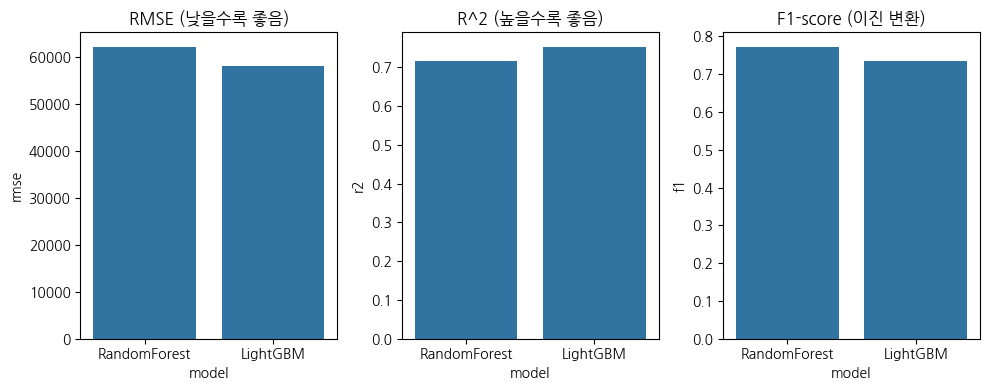

          model          rmse        r2        f1
0  RandomForest  62074.188152  0.716820  0.771858
1      LightGBM  58014.736637  0.752647  0.735243

가장 성능 좋은 모델: LightGBM
최적 하이퍼파라미터: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 0.9112327162102557, 'importance_type': 'split', 'learning_rate': 0.16753782926518682, 'max_depth': 9, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 163, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.7441647290861407, 'subsample_for_bin': 200000, 'subsample_freq': 0}


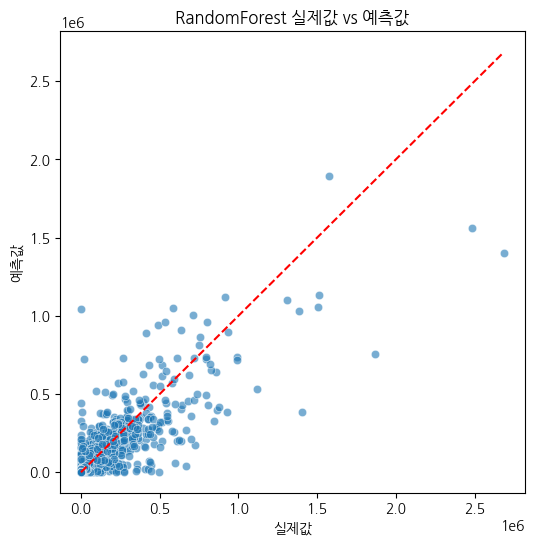

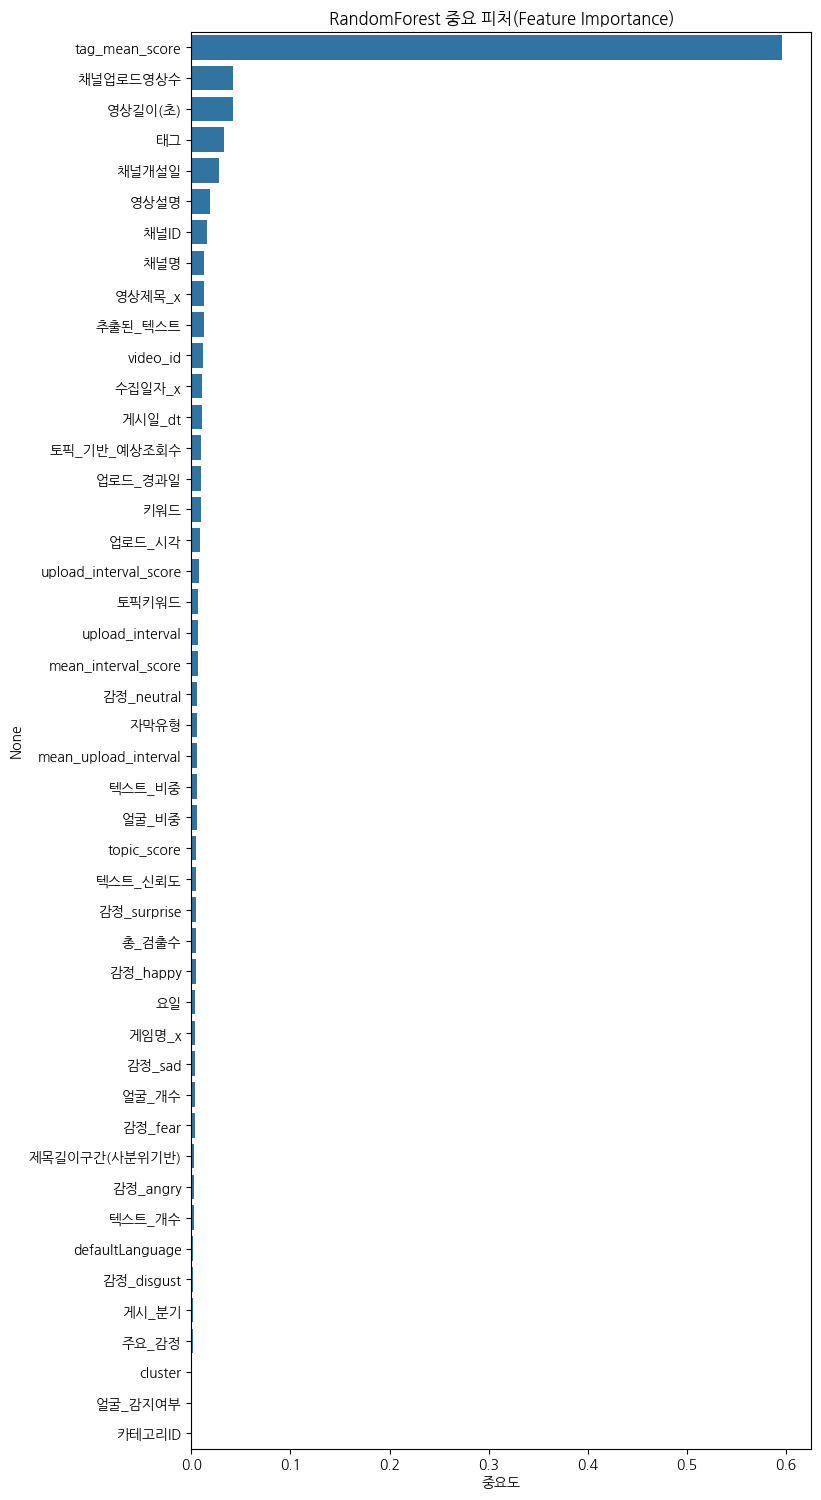

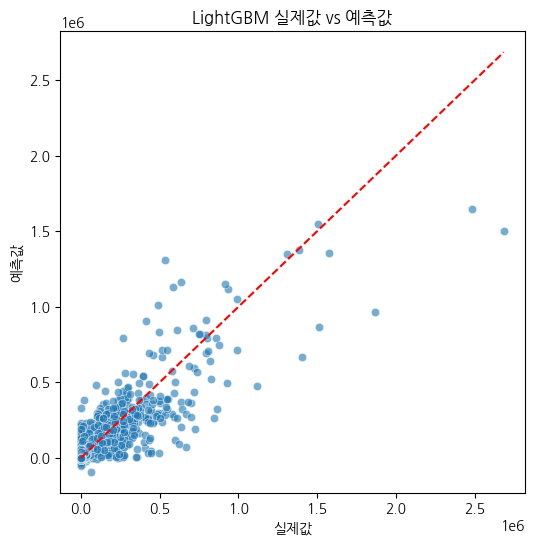

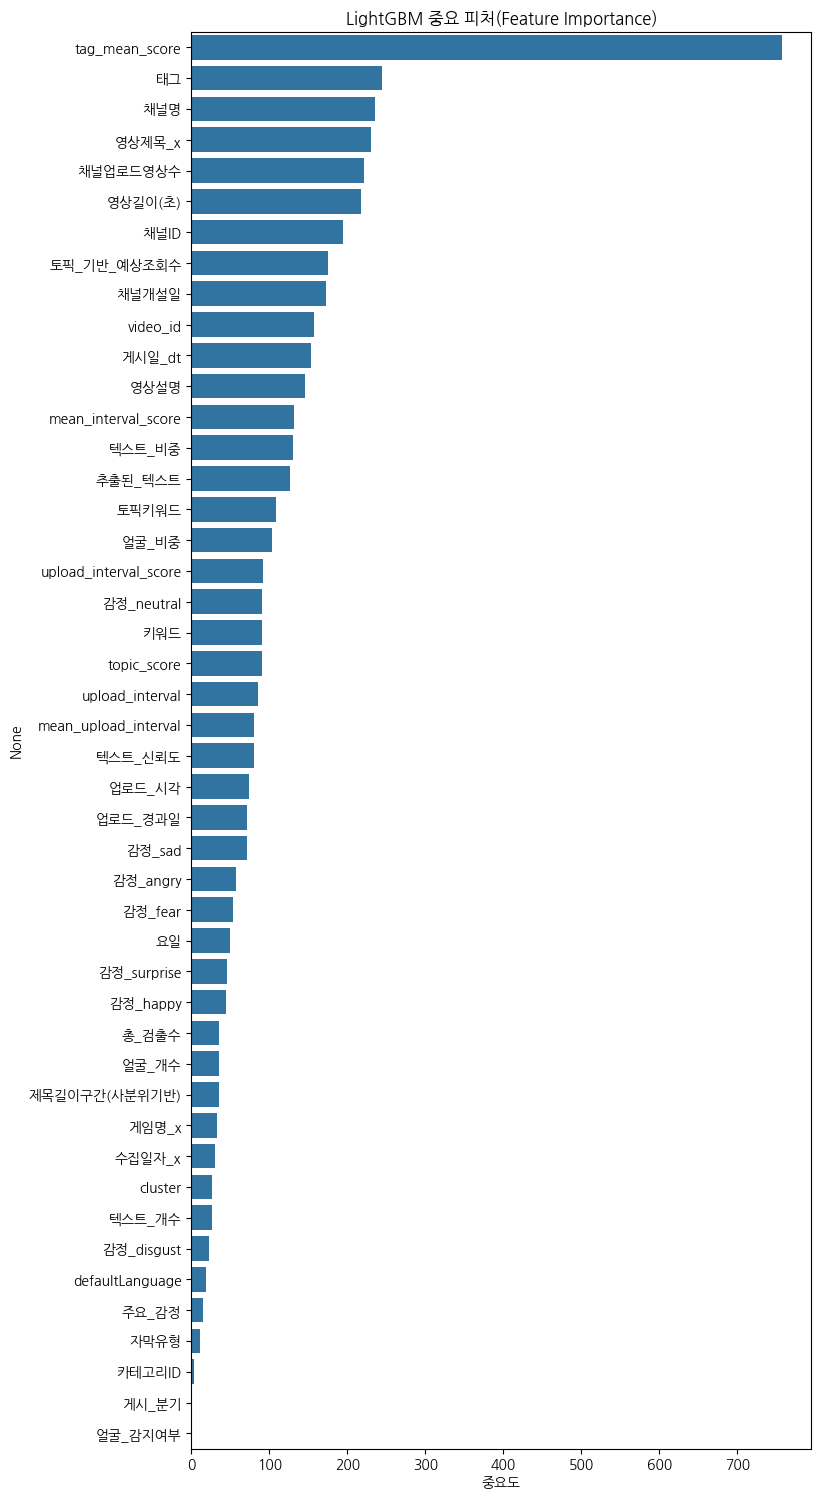

In [26]:
# 1. 한글 폰트 설치 및 적용 (코랩 전용)
# !apt-get update -qq
# !apt-get install -qq fonts-nanum
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

plt.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. 라이브러리 설치 (필요시)
!pip install optuna xgboost lightgbm scikit-learn pandas

# 3. 파일 경로 설정 및 존재 확인
import os
file_path = 'final_data_0609.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {file_path}")

# 4. 데이터 업로드 및 전처리
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(file_path, encoding='utf-8')
print("데이터 shape:", df.shape)
print("컬럼 목록:", list(df.columns))

target = '조회수'
if target not in df.columns:
    raise ValueError(f"'{target}' 컬럼이 데이터에 없습니다.")

# 결측치 제거 (타겟)
df = df.dropna(subset=[target])
X = df.drop([target], axis=1)
y = df[target]

# 범주형 인코딩 (모든 object 컬럼)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 결측치 완전 제거 (중요!)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 컬럼별 조회수 상관관계 시각화
corrs = pd.concat([X, y], axis=1).corr()[target].drop(target)
plt.figure(figsize=(10, 0.5*len(corrs)))
sns.barplot(x=corrs.values, y=corrs.index, orient='h')
plt.title('컬럼별 조회수 상관관계')
plt.xlabel('상관계수')
plt.show()

# 6. 회귀 모델별 Optuna 하이퍼파라미터 튜닝 함수 정의
import optuna
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, f1_score

def regression_objective(trial, model_name):
    if model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**params)
    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'n_jobs': -1
        }
        model = LGBMRegressor(**params)
    else:
        raise ValueError('지원하지 않는 모델')

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    return rmse

# 7. 각 모델별 Optuna 튜닝 및 결과 저장
model_names = ['RandomForest', 'LightGBM']
best_models = {}
results = []

for model_name in model_names:
    print(f"Optuna 튜닝 시작: {model_name}")
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: regression_objective(trial, model_name), n_trials=20)
    if model_name == 'RandomForest':
        model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
    elif model_name == 'LightGBM':
        model = LGBMRegressor(**study.best_params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    y_pred_bin = (preds > np.median(y_train)).astype(int)
    y_true_bin = (y_test > np.median(y_train)).astype(int)
    f1 = f1_score(y_true_bin, y_pred_bin)
    best_models[model_name] = model
    results.append({'model': model_name, 'rmse': rmse, 'r2': r2, 'f1': f1})

# 8. 모델별 성능 비교 시각화
results_df = pd.DataFrame(results)
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
sns.barplot(x='model', y='rmse', data=results_df)
plt.title('RMSE (낮을수록 좋음)')
plt.subplot(1,3,2)
sns.barplot(x='model', y='r2', data=results_df)
plt.title('R^2 (높을수록 좋음)')
plt.subplot(1,3,3)
sns.barplot(x='model', y='f1', data=results_df)
plt.title('F1-score (이진 변환)')
plt.tight_layout()
plt.show()

print(results_df)

# 9. 가장 성능 좋은 모델 및 하이퍼파라미터 출력
best_row = results_df.sort_values('rmse').iloc[0]
print(f"\n가장 성능 좋은 모델: {best_row['model']}")
print("최적 하이퍼파라미터:", best_models[best_row['model']].get_params())

# 10. 각 모델별 실제값 vs 예측값, Feature Importance 시각화
for model_name in model_names:
    model = best_models[model_name]
    preds = model.predict(X_test)

    # 실제값 vs 예측값 산점도
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test, y=preds, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
    plt.title(f'{model_name} 실제값 vs 예측값')
    plt.xlabel('실제값')
    plt.ylabel('예측값')
    plt.show()

    # Feature Importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        plt.figure(figsize=(8, 0.4*len(X.columns)))
        sns.barplot(x=importances[indices], y=X.columns[indices])
        plt.title(f'{model_name} 중요 피처(Feature Importance)')
        plt.xlabel('중요도')
        plt.show()


데이터 shape: (4874, 47)
컬럼 목록: ['수집일자_x', '게임명_x', 'video_id', '영상제목_x', '영상설명', '채널ID', '채널명', '태그', '카테고리ID', 'defaultLanguage', '영상길이(초)', '채널업로드영상수', '채널개설일', '자막유형', 'cluster', 'topic_score', '게시일_dt', '업로드_시각', '업로드_경과일', '게시_분기', '요일', '조회수', '추출된_텍스트', '키워드', '텍스트_개수', '텍스트_신뢰도', '총_검출수', '텍스트_비중', '주요_감정', '얼굴_감지여부', '얼굴_개수', '얼굴_비중', '감정_angry', '감정_disgust', '감정_fear', '감정_happy', '감정_sad', '감정_surprise', '감정_neutral', 'upload_interval', 'mean_upload_interval', 'upload_interval_score', 'mean_interval_score', 'tag_mean_score', '토픽키워드', '토픽_기반_예상조회수', '제목길이구간(사분위기반)']


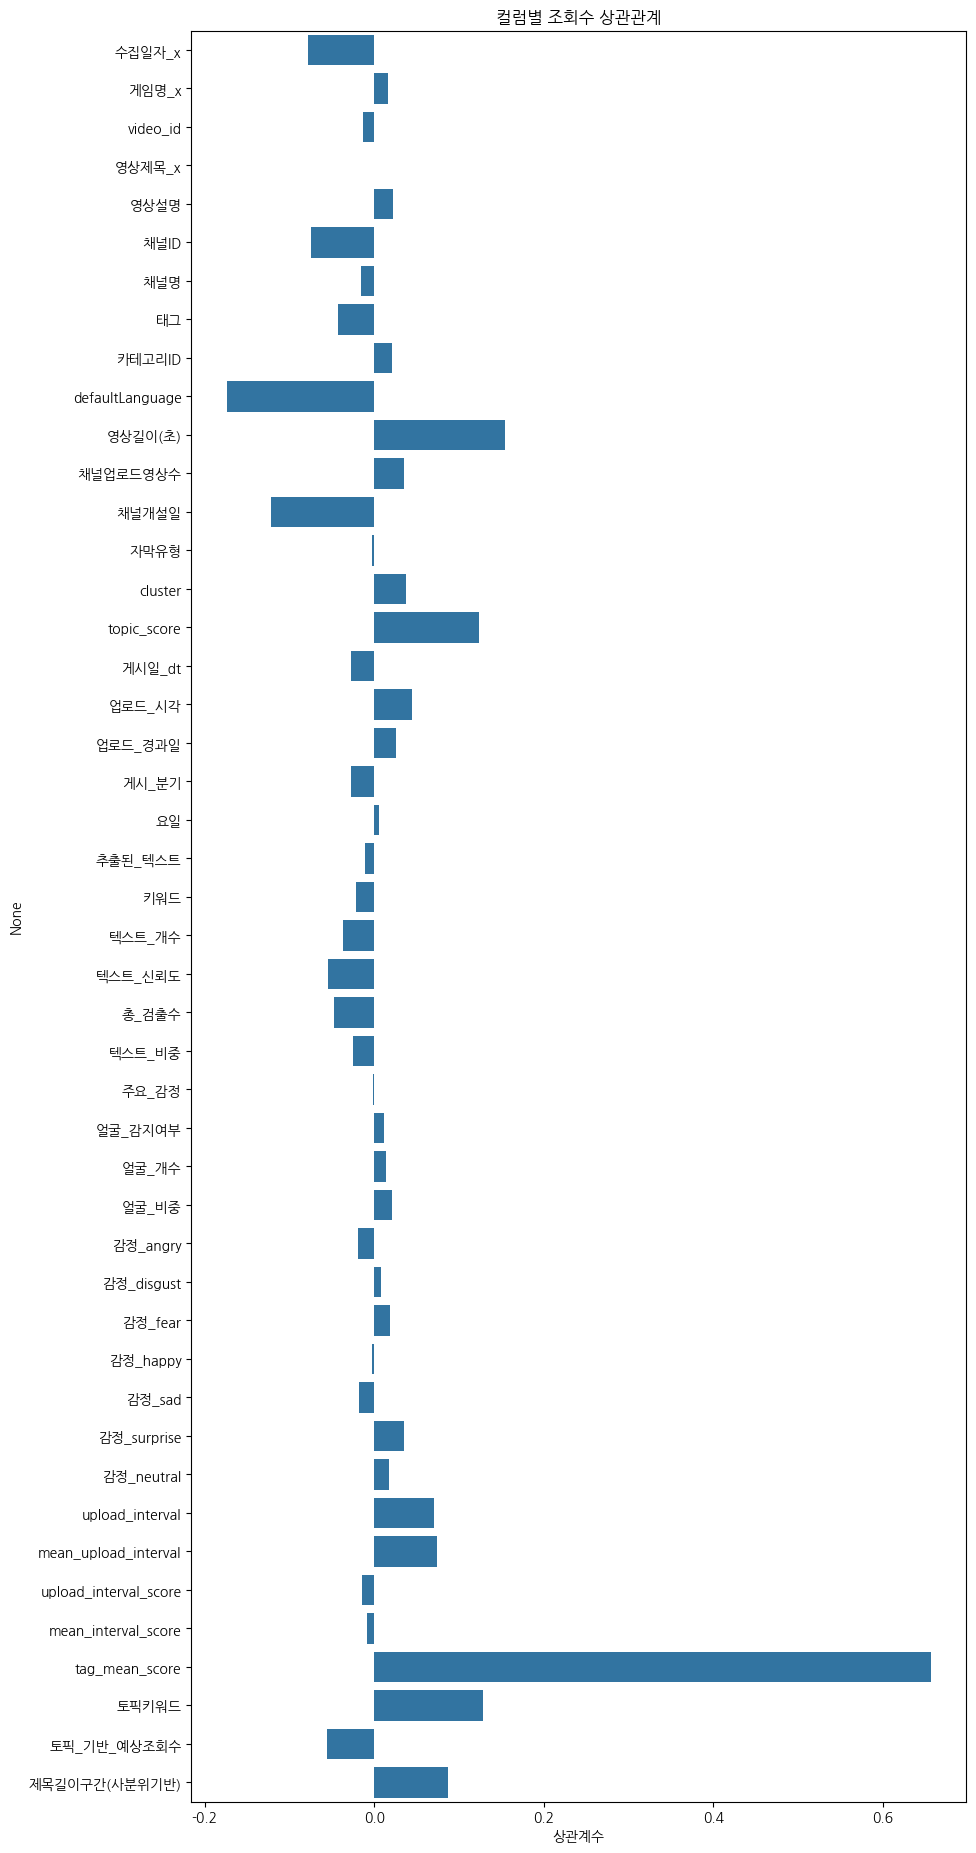

[I 2025-06-09 10:16:42,636] A new study created in memory with name: no-name-49bb8f64-33be-4ba1-b273-d9bd4f1a863c


Optuna 튜닝 시작: RandomForest


[I 2025-06-09 10:17:12,894] Trial 0 finished with value: 154264.6517909127 and parameters: {'n_estimators': 260, 'max_depth': 28, 'min_samples_split': 9}. Best is trial 0 with value: 154264.6517909127.
[I 2025-06-09 10:17:27,482] Trial 1 finished with value: 155077.37507516146 and parameters: {'n_estimators': 221, 'max_depth': 15, 'min_samples_split': 20}. Best is trial 0 with value: 154264.6517909127.
[I 2025-06-09 10:17:33,945] Trial 2 finished with value: 156434.4286913067 and parameters: {'n_estimators': 96, 'max_depth': 12, 'min_samples_split': 12}. Best is trial 0 with value: 154264.6517909127.
[I 2025-06-09 10:17:40,460] Trial 3 finished with value: 156920.36945889945 and parameters: {'n_estimators': 89, 'max_depth': 22, 'min_samples_split': 12}. Best is trial 0 with value: 154264.6517909127.
[I 2025-06-09 10:17:47,760] Trial 4 finished with value: 160246.11358768182 and parameters: {'n_estimators': 242, 'max_depth': 5, 'min_samples_split': 9}. Best is trial 0 with value: 154264

Optuna 튜닝 시작: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005286 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5968
[LightGBM] [Info] Number of data points in the train set: 3898, number of used features: 46
[LightGBM] [Info] Start training from score 201459.512057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

[I 2025-06-09 10:21:32,859] Trial 0 finished with value: 153209.40219435634 and parameters: {'n_estimators': 277, 'max_depth': 7, 'learning_rate': 0.16091511624693763, 'subsample': 0.8428848441511981, 'colsample_bytree': 0.8279471097135747}. Best is trial 0 with value: 153209.40219435634.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002401 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5968
[LightGBM] [Info] Number of data points in the train set: 3898, number of used features: 46
[LightGBM] [Info] Start training from score 201459.512057


[I 2025-06-09 10:21:42,077] Trial 18 finished with value: 149948.2378963904 and parameters: {'n_estimators': 95, 'max_depth': 13, 'learning_rate': 0.13161196922092344, 'subsample': 0.8321670127299814, 'colsample_bytree': 0.6423056716027583}. Best is trial 6 with value: 149453.87850255106.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5968
[LightGBM] [Info] Number of data points in the train set: 3898, number of used features: 46
[LightGBM] [Info] Start training from score 201459.512057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

[I 2025-06-09 10:21:42,720] Trial 19 finished with value: 150472.44858057596 and parameters: {'n_estimators': 224, 'max_depth': 9, 'learning_rate': 0.04654310886368626, 'subsample': 0.591310181671199, 'colsample_bytree': 0.8321195327272568}. Best is trial 6 with value: 149453.87850255106.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

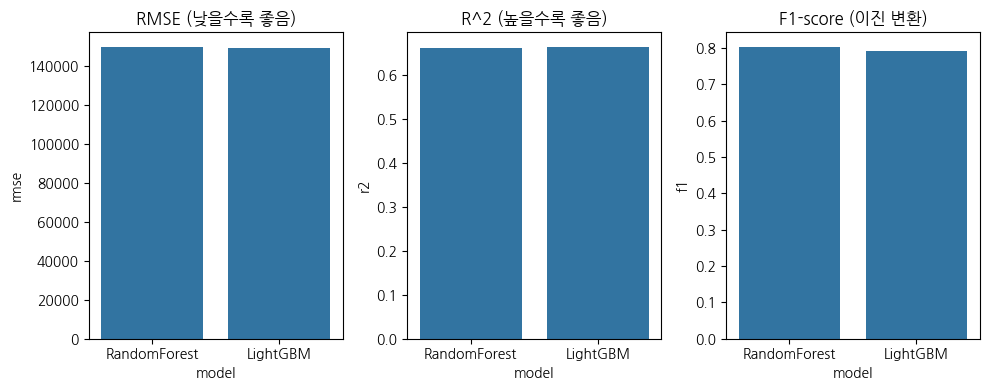

          model           rmse        r2       f1
0  RandomForest  149803.139634  0.662522  0.80248
1      LightGBM  149453.878503  0.664094  0.79115

가장 성능 좋은 모델: LightGBM
최적 하이퍼파라미터: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 0.8055484015124785, 'importance_type': 'split', 'learning_rate': 0.0633528282771878, 'max_depth': 12, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 93, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.8815811377724074, 'subsample_for_bin': 200000, 'subsample_freq': 0}


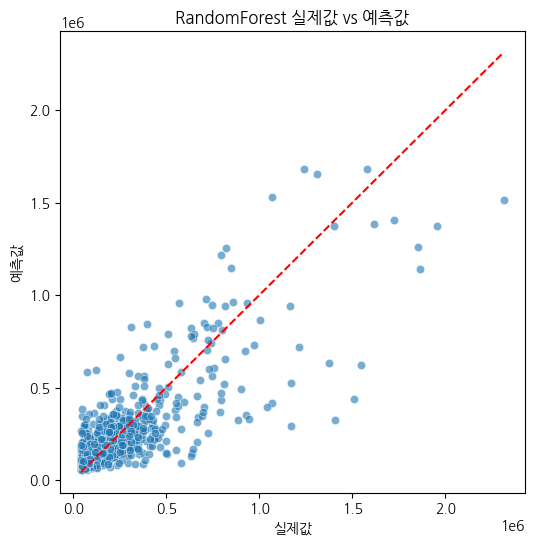

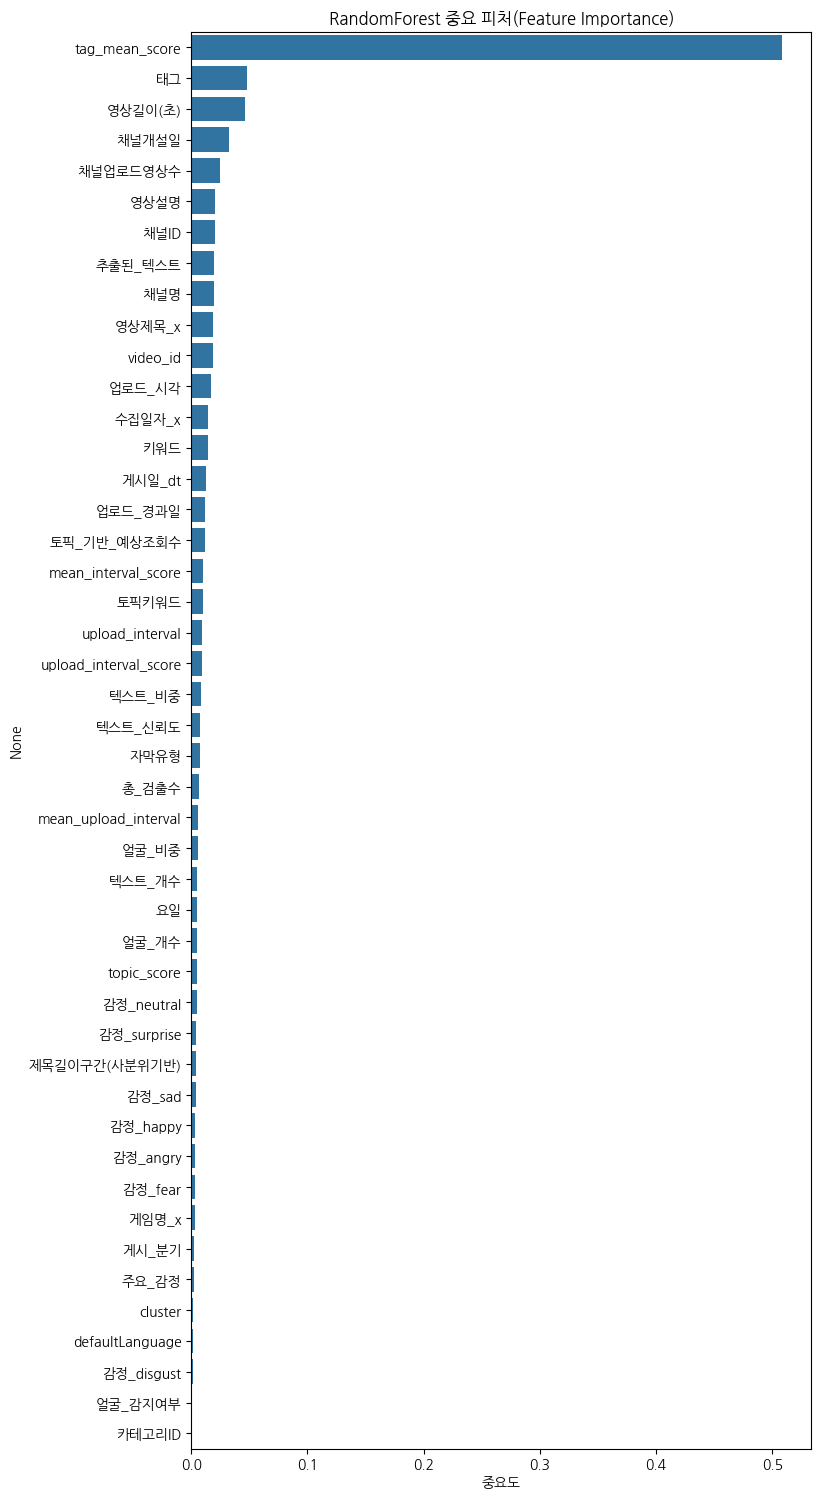

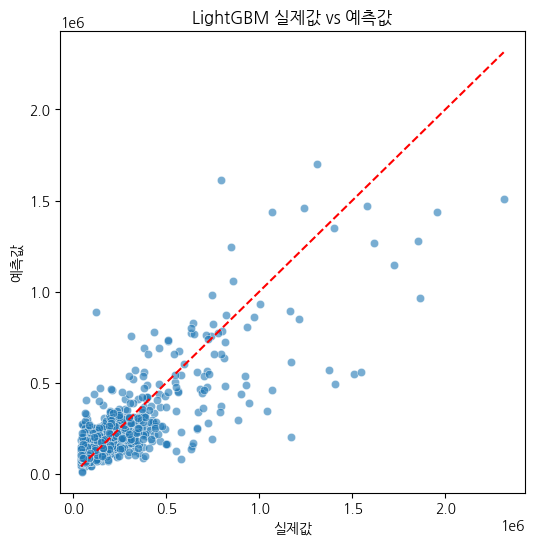

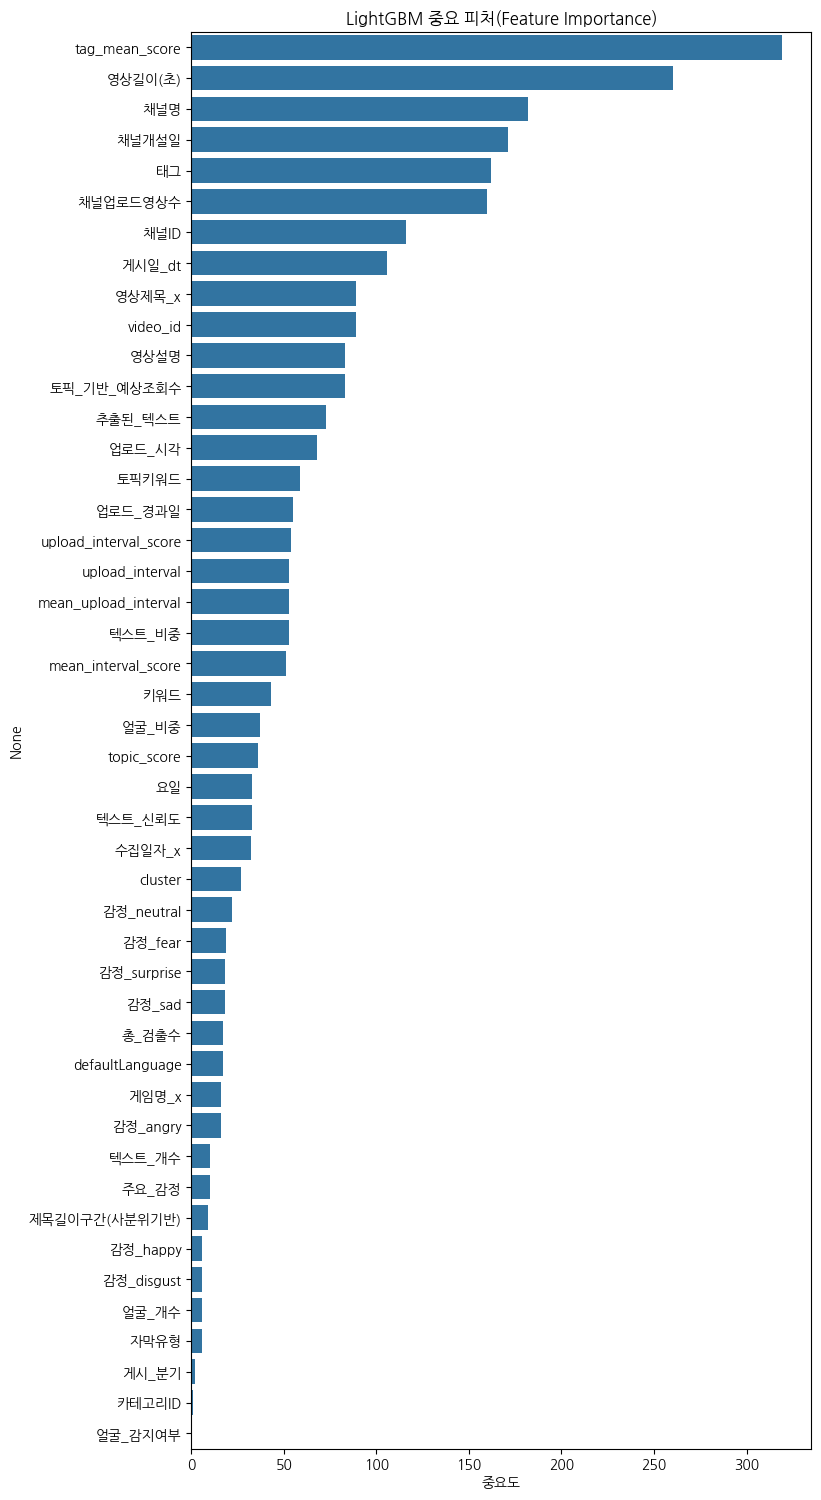


[컬럼별로 조회수 상승 전략 제시]

업로드 시각별 평균 조회수 상위 10개
업로드_시각
18.0    540203.411765
19.0    380164.235294
17.0    280173.277778
16.0    255825.937500
10.0    241877.673267
12.0    237104.226087
14.0    221038.048780
4.0     219217.620155
20.0    218377.222222
15.0    212845.785714
Name: 조회수, dtype: float64


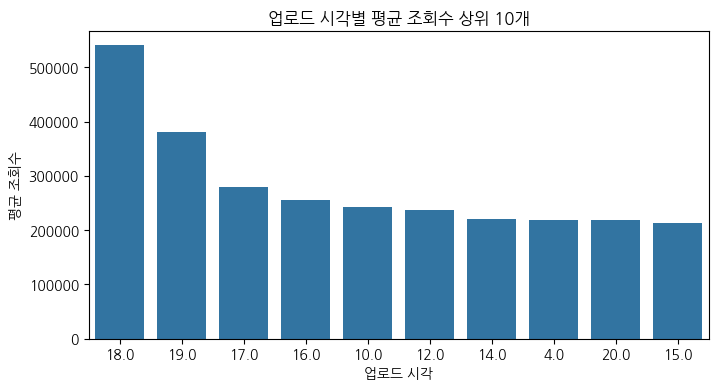


키워드별 평균 조회수 상위 20개
키워드
Mara_zzang, Chicken_zzang, Secom_zzang    2826061.0
제로0000, tlqkf, 상황발생, JuslLikeThalkR       2779800.0
(애디), (초비)                                2754394.0
89조587억, 90조p유왼생, SHARP                   2543667.0
15, DDDh, FOR                             2485884.0
ZEUs, DNER, FAKER, KERIA                  2438976.0
ROSE, TOGETHER, HUSE                      2313973.0
배그프로, 75명, 3명                             2013876.0
월드컵, 결승, TIvsBLG                          2012618.0
HOr, 체임버                                  1956590.0
MATCH2, GEN                               1950713.0
Da                                        1932096.0
통마무스, Pay                                 1881538.0
I8                                        1864895.0
가시, 감옷, 기본, 공격, 방어                        1854161.0
이터하래리뷰                                    1831396.0
챔스, Vs                                    1645788.0
VOICE, COMMS                              1615266.0
Gumayusi, Zeus, Oner, Faker             

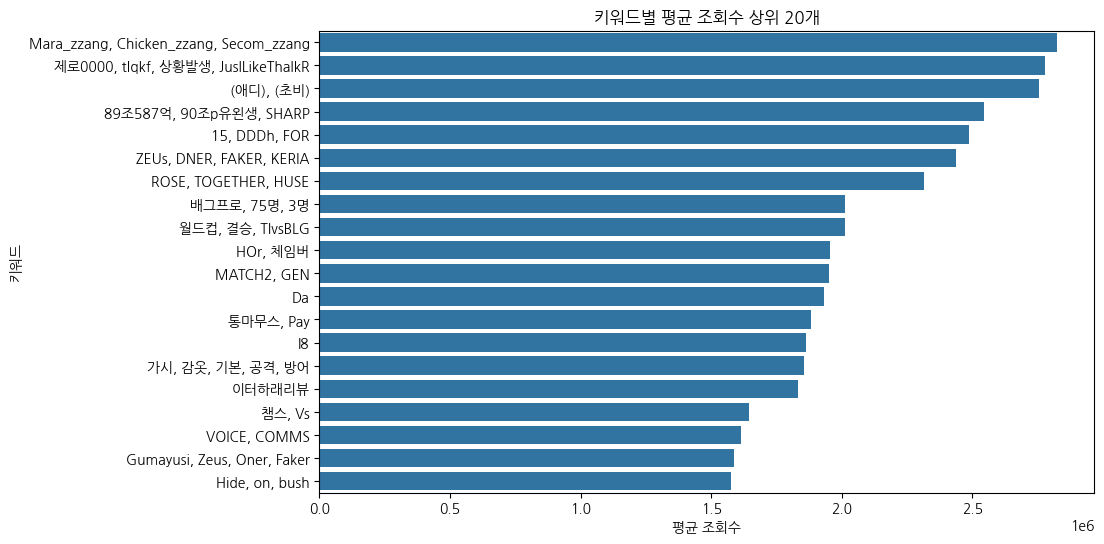


수집일자_x별 평균 조회수 상위 10개
수집일자_x
2025-05-18    299830.393258
2025-05-17    267628.214765
2025-05-19    218010.256293
2025-05-20    210392.055528
2025-05-22    187703.571429
Name: 조회수, dtype: float64


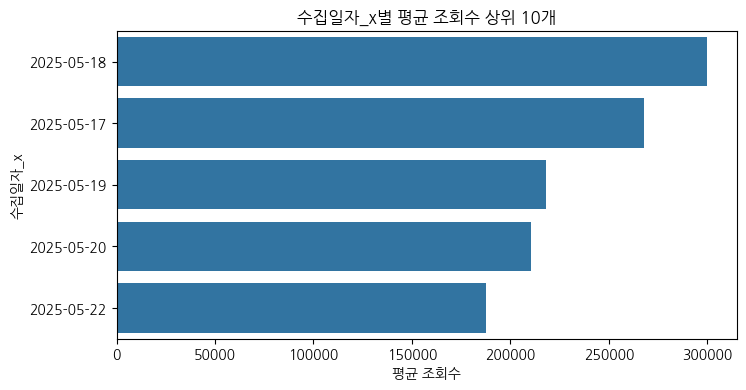


게임명_x별 평균 조회수 상위 10개
게임명_x
배틀그라운드    279081.316239
롤         263034.754823
발로란트      177532.184448
FC온라인     146373.014706
서든        127428.882812
Name: 조회수, dtype: float64


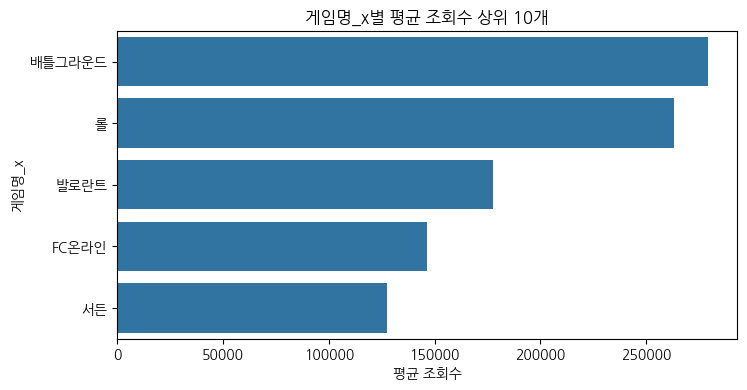


video_id별 평균 조회수 상위 10개
video_id
Oy-FiEZ2U-0    2826061.0
VoX6Th7tW-8    2779800.0
IgU0hkCuOM0    2754394.0
51Gzh7v9gNs    2685162.0
i_ugYZQjKW4    2635816.0
AOX2P1tol0c    2543667.0
MPcUGG8zvrc    2485884.0
s47X4a2OjYA    2438976.0
czKe4FqiiyY    2313973.0
mFVOWiPHacM    2013876.0
Name: 조회수, dtype: float64


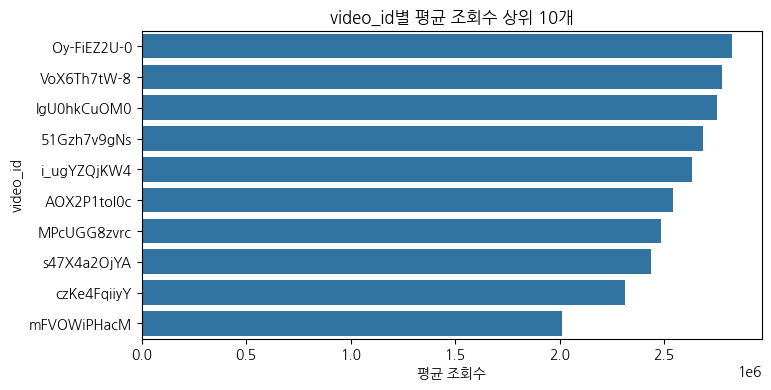


영상제목_x별 평균 조회수 상위 10개
영상제목_x
스쿼드에 나 혼자만 남자면 생기는 일ㅋㅋㅋㅋㅋㅋㅇㅏㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ    2826061.0
시즌 종료까지 1시간, 챌린저까지 40점남은 저라뎃 저격 성공 ㅋㅋㅋㅋ                2779800.0
맥문철TV 번외. "씨맥님 이 라인 밀어야 하지 않나요?"                       2754394.0
뜨거운 X끼                                                 2685162.0
상스러운 놈                                                 2635816.0
감스트 본캐 팀다팔고 90조 맨유금카팀 맞췄습니다!!                          2543667.0
새로운 왕조의 탄생 [T1scord 2024 Ep.18]                        2485884.0
FAKER [EP. 2] : La G?n?ration des Miracles.            2438976.0
함께 날아오르다 | T1 Rose Together                            2313973.0
왁타버스 75명이 프로 25명을 이길 수 있을까? - 배그 3배싸움                  2013876.0
Name: 조회수, dtype: float64


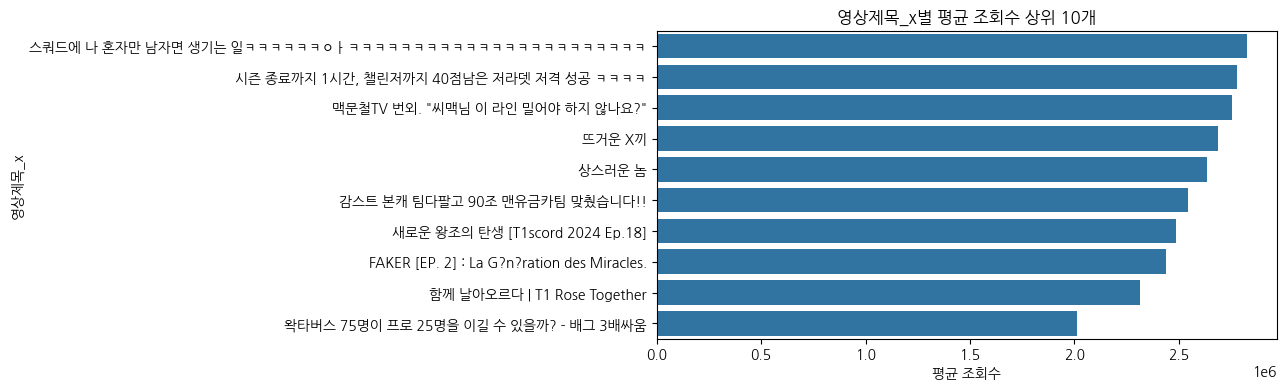


영상설명별 평균 조회수 상위 10개
영상설명
꿔바로우 짱\n[업로드] 금,토,일,월 \n[문의메일] zxcv34276@gmail.com\n[인스타그램] @hxxax_\n#혜안 #배틀그라운드\nMusic by 달콤사운즈\n‘Pop Pop’ - https://youtu.be/nLMmhfe29bE?si=0qgNiqlVhQFbeN0i\nMusic by 브그밍 \nlittle rascal ? https://youtu.be/pOgGO8Ey5w0\nMusic provided by 브금대통령\nTrack : Keep The Tension 2 - https://youtu.be/ex7o_PDQg9g\nTrack : MJ Junior - https://youtu.be/HUj5e5zF8is\nTrack : Dungeon in Game - https://youtu.be/423emP-Dbl8\nTrack : 펭귄의 비행 - https://youtu.be/ZW_msPN4GJw\nMusic provided by DJ곡쓴이\nOUT - https://youtu.be/4QmvukgjpGg\nIrony ? https://youtu.be/uWCJ4pqFAgA\n그냥 놀자 ? https://youtu.be/7adONIyGgHE\nMusic composed by 브금술사_BGMmagician\nTrack : 조심 좀 하지 그랬어 - https://youtu.be/JINIlUeQSoo                                                                                                                                                                                                                                                                                                     

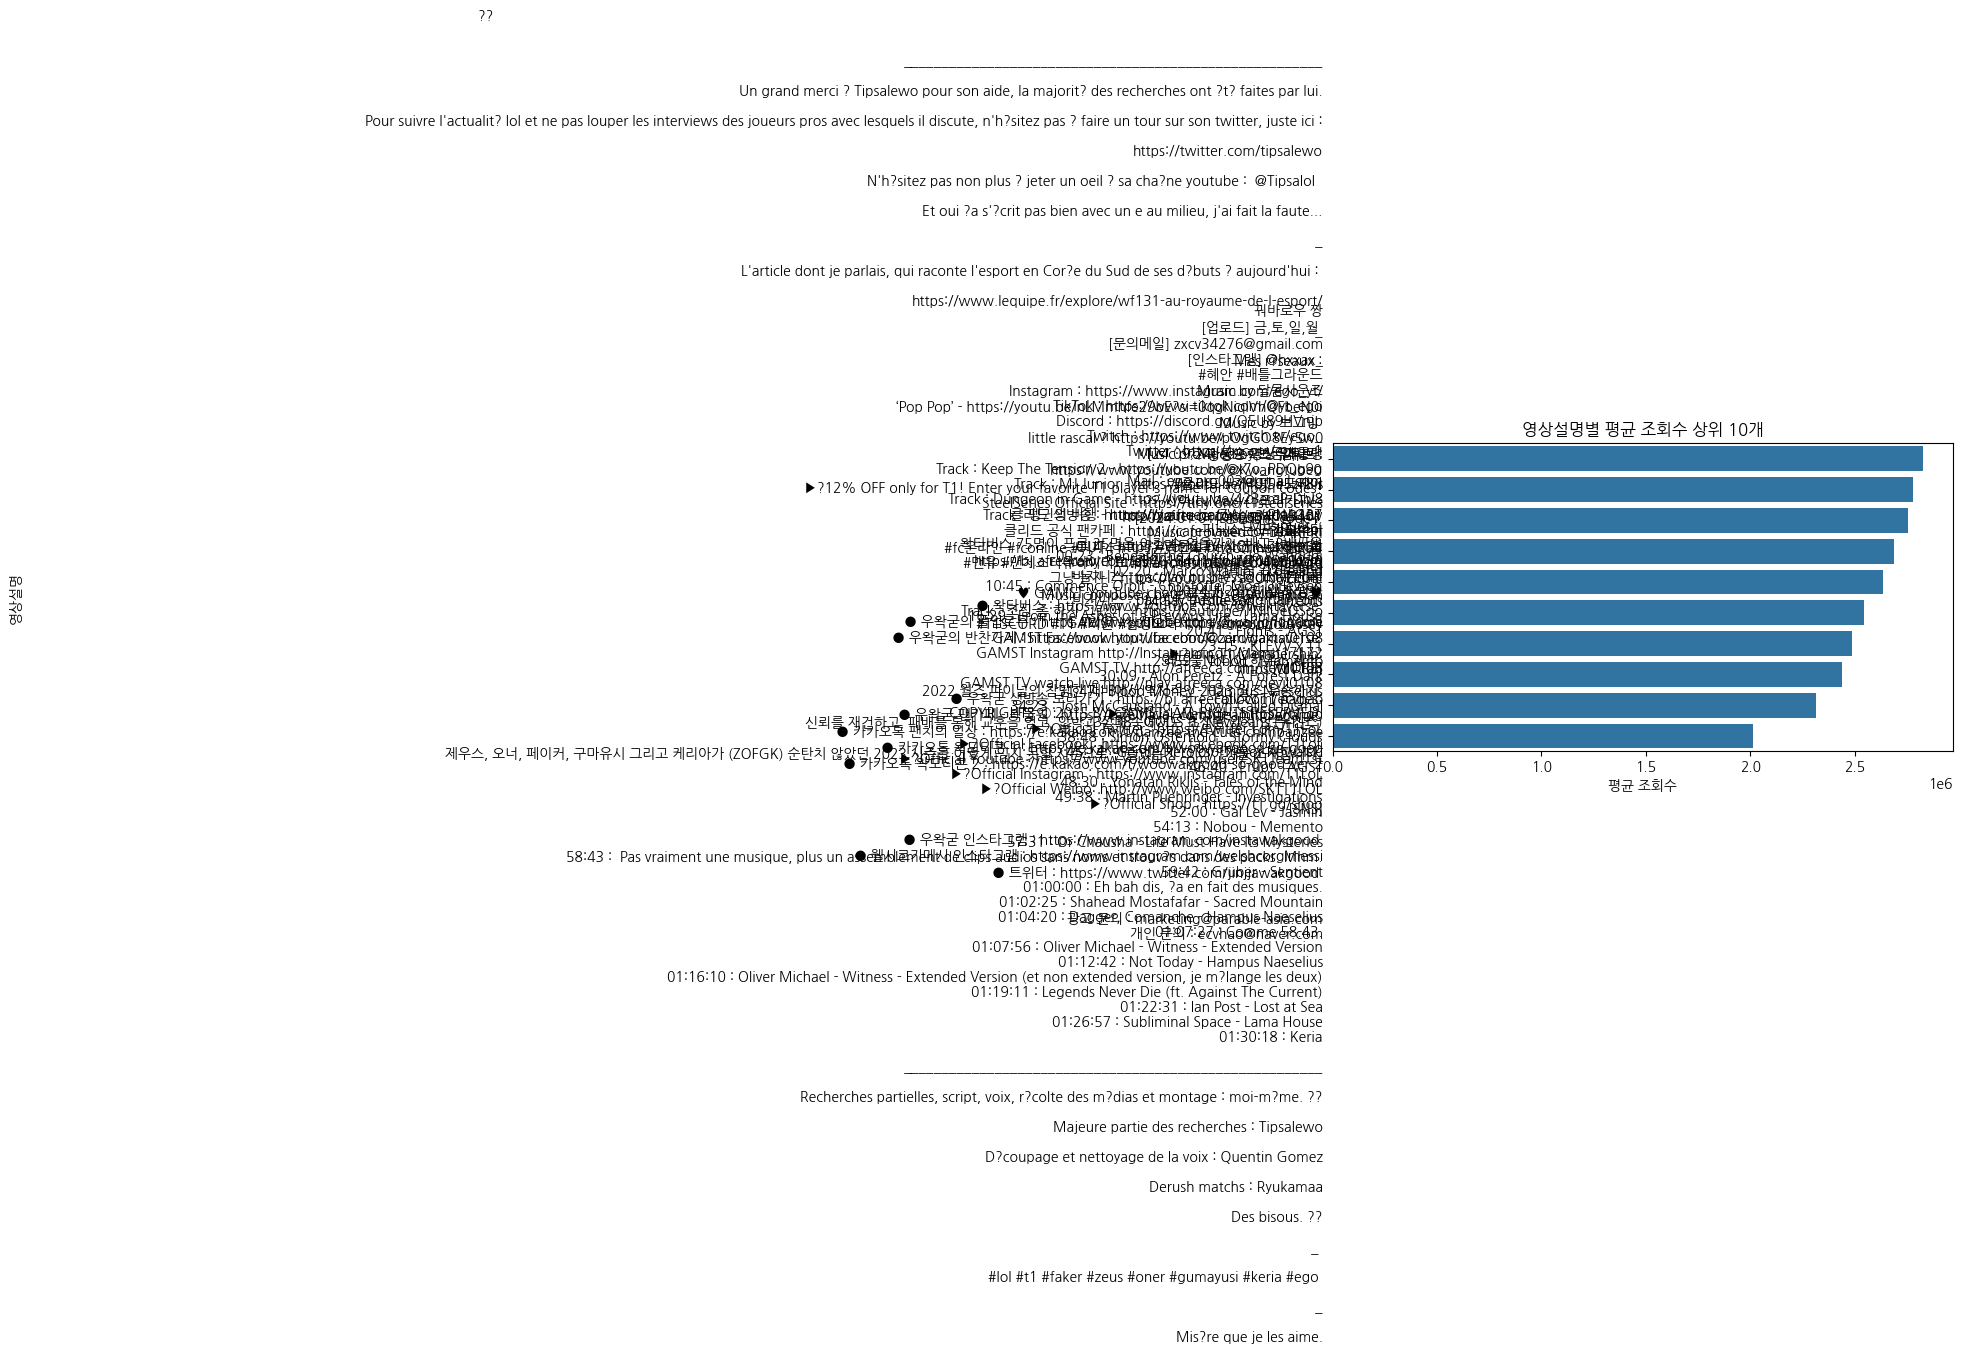


채널ID별 평균 조회수 상위 10개
채널ID
UCxH16958KSxT4Z9yL_9JYtw    2.438976e+06
UCNHzi1aZaQZOgVX38E2M4iw    1.898435e+06
UCqX4HxMPVdAsvfd9BC-C2wQ    1.627556e+06
UCJprx3bX49vNl6Bcw01Cwfg    1.618752e+06
UCYFjd1gFMY7p39ZtsQ2quRA    1.588804e+06
UCv-HJGOUupbVHCEBRdcLuVA    1.464029e+06
UCD2YO_A_PVMgMDN9jpRrpVA    1.462186e+06
UCsU-I-vHLiaMfV_ceaYz5rQ    1.334333e+06
UC4P7F8qenDo1O_5NvgBb_cg    1.240629e+06
UCHBzepJnvhFXCQDT4B181hg    1.225570e+06
Name: 조회수, dtype: float64


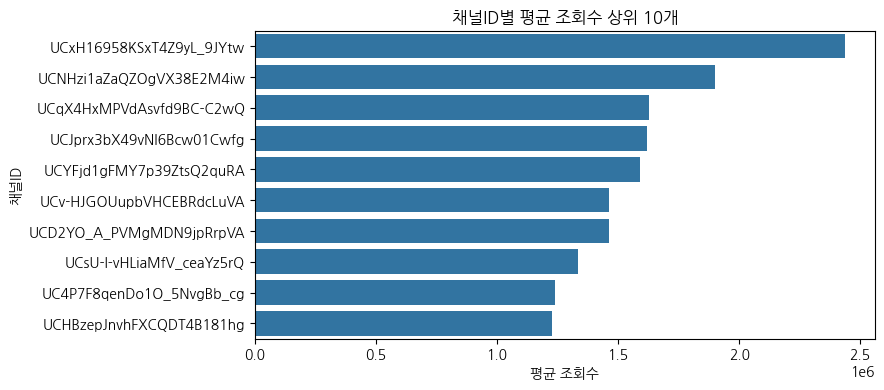


채널명별 평균 조회수 상위 10개
채널명
EGO               2.438976e+06
맛좋은호박벌            1.898435e+06
cvMax             1.627556e+06
T1                1.618752e+06
김수당 SOODANGKIM    1.588804e+06
180초              1.464029e+06
랄로                1.462186e+06
JTBC News         1.334333e+06
발스타홍구             1.240629e+06
Ju1st             1.225570e+06
Name: 조회수, dtype: float64


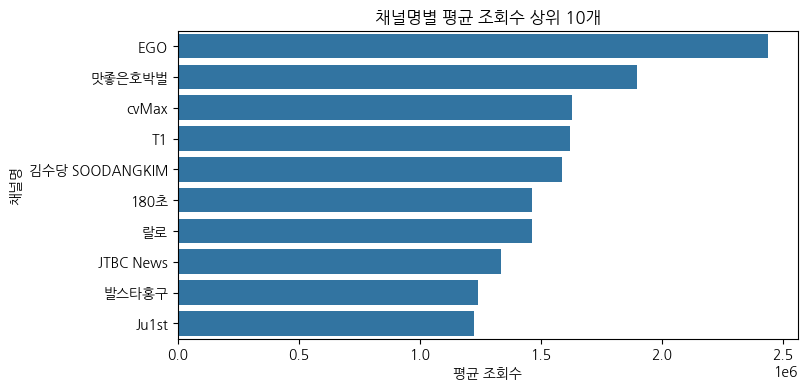


태그별 평균 조회수 상위 10개
태그
혜안, 론도                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               2826061.00
클리드, 저라뎃, 롤, 프레이                                                                                                                                                                                                                                                                                                                                                                                                                                  

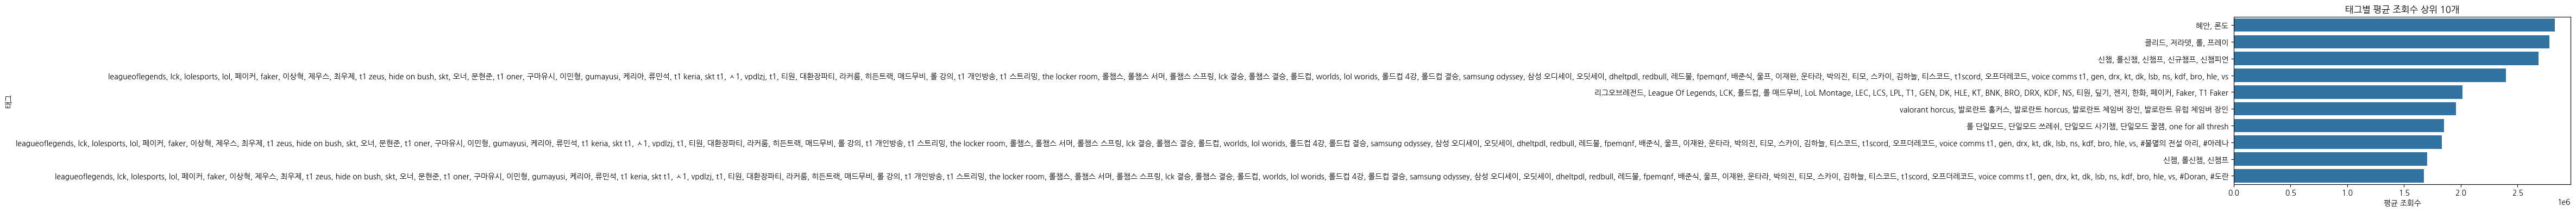


defaultLanguage별 평균 조회수 상위 10개
defaultLanguage
ko       286916.201082
en       223265.500000
en-US     88994.400000
sv        73331.000000
Name: 조회수, dtype: float64


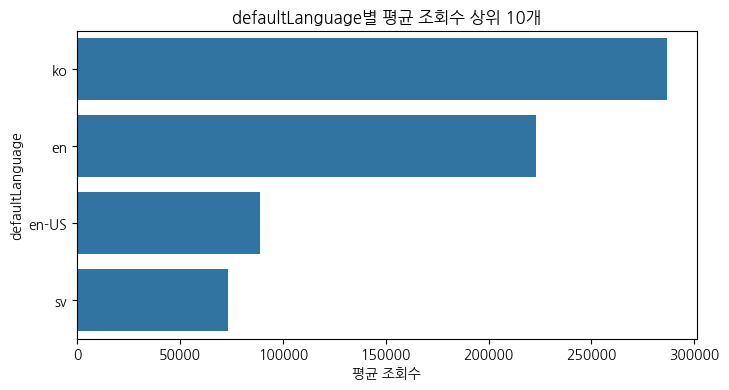


채널개설일별 평균 조회수 상위 10개
채널개설일
2021-09-14T22:27:50.387675Z    2.438976e+06
2023-07-04T00:13:53.451642Z    1.898435e+06
2016-02-18T08:07:29Z           1.627556e+06
2011-06-01T08:15:47Z           1.618752e+06
2022-06-16T08:57:04.720602Z    1.588804e+06
2022-03-15T11:51:18.994213Z    1.464029e+06
2013-11-14T05:32:35Z           1.462186e+06
2012-02-21T07:43:44Z           1.334333e+06
2020-04-04T08:23:12.214305Z    1.240629e+06
2022-10-16T20:37:13.878046Z    1.225570e+06
Name: 조회수, dtype: float64


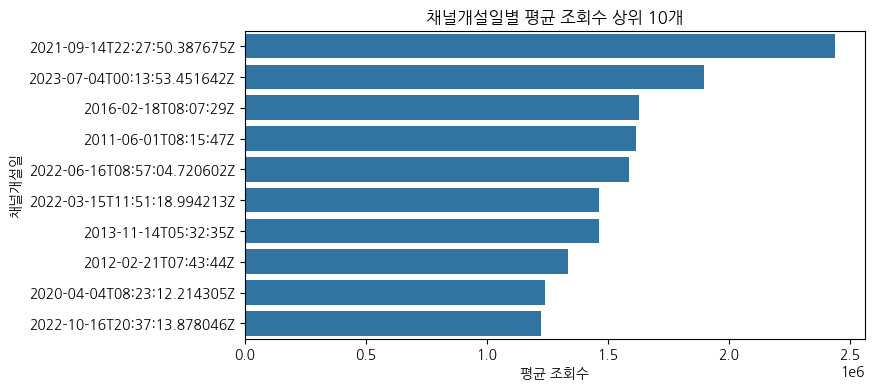


자막유형별 평균 조회수 상위 10개
자막유형
en          358558.421053
skip        319238.337662
none        200381.850858
ko          199815.531907
disabled    191297.500000
Name: 조회수, dtype: float64


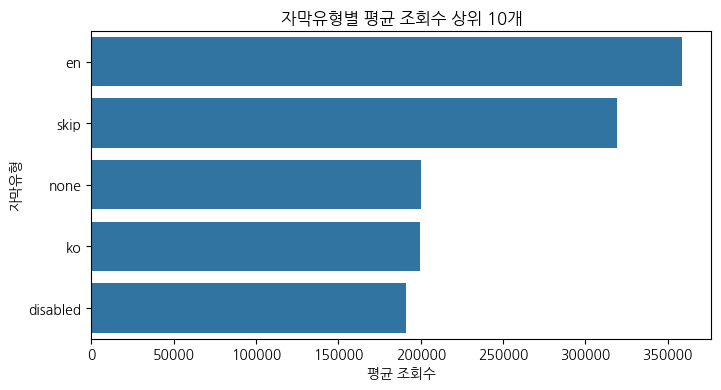


게시일_dt별 평균 조회수 상위 10개
게시일_dt
2024-01-29 9:28     2826061.0
2024-09-26 9:15     2779800.0
2024-02-22 19:42    2754394.0
2024-05-19 12:58    2685162.0
2024-02-05 11:30    2635816.0
2024-11-10 18:17    2485884.0
2024-02-23 15:20    2438976.0
2024-09-20 11:00    2313973.0
2024-07-18 8:09     2013876.0
2024-11-03 4:42     2012618.0
Name: 조회수, dtype: float64


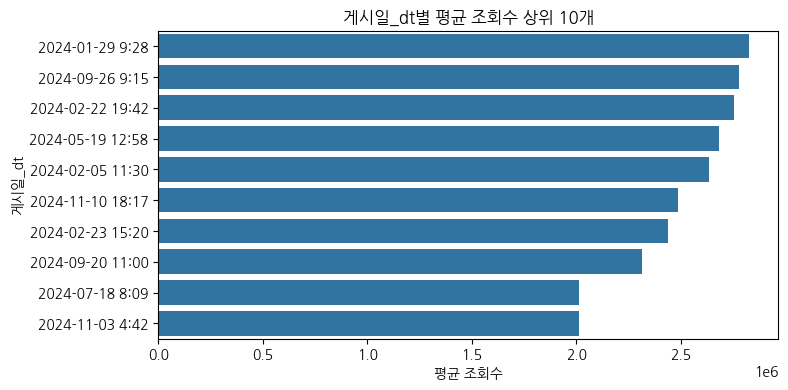


요일별 평균 조회수 상위 10개
요일
금요일    218045.400000
월요일    216704.672205
토요일    215700.312500
일요일    209416.039416
화요일    196226.081761
목요일    185256.268477
수요일    184429.463636
Name: 조회수, dtype: float64


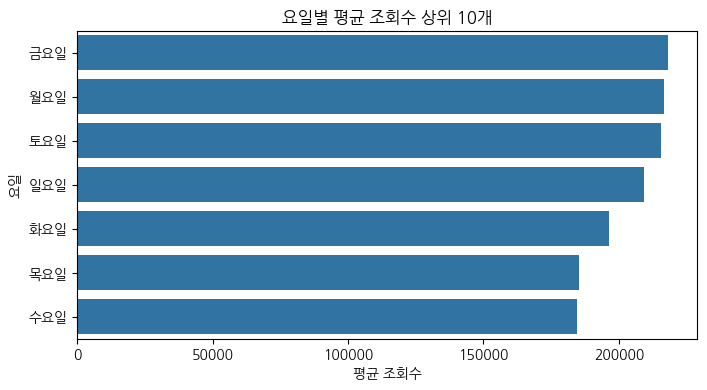


추출된_텍스트별 평균 조회수 상위 10개
추출된_텍스트
2 Mara_zzang 3 Chicken_zzang Secom_zzang 나어 (    2826061.0
제로0000 아 tlqkf! '상황발생 JuslLikeThalkR             2779800.0
(애디) ???? (초비)                                   2754394.0
89조587억 90조p유왼생 SHARP                            2543667.0
15 DDDh FOR                                      2485884.0
ZEUs DNER FAKER KERIA                            2438976.0
ROSE TOGETHER HUSE                               2313973.0
(배그프로) 75명 3명                                    2013876.0
월드컵 결승 TIvsBLG                                   2012618.0
HOr 체임버 신                                        1956590.0
Name: 조회수, dtype: float64


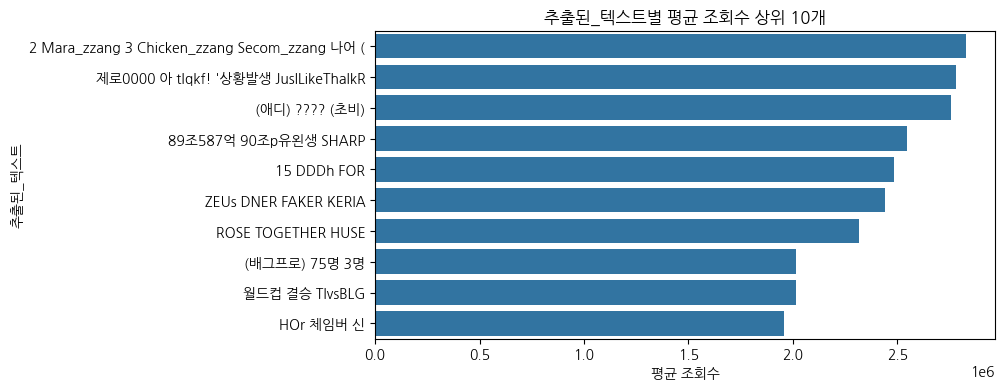


키워드별 평균 조회수 상위 10개
키워드
Mara_zzang, Chicken_zzang, Secom_zzang    2826061.0
제로0000, tlqkf, 상황발생, JuslLikeThalkR       2779800.0
(애디), (초비)                                2754394.0
89조587억, 90조p유왼생, SHARP                   2543667.0
15, DDDh, FOR                             2485884.0
ZEUs, DNER, FAKER, KERIA                  2438976.0
ROSE, TOGETHER, HUSE                      2313973.0
배그프로, 75명, 3명                             2013876.0
월드컵, 결승, TIvsBLG                          2012618.0
HOr, 체임버                                  1956590.0
Name: 조회수, dtype: float64


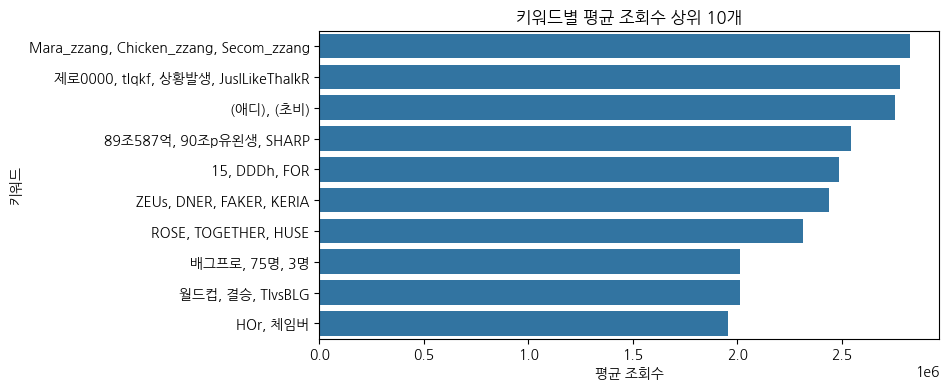


주요_감정별 평균 조회수 상위 10개
주요_감정
surprise    251100.813793
disgust     218061.263158
fear        217073.618343
neutral     212111.349436
unknown     201602.722005
happy       199232.598814
sad         196181.151042
angry       193788.323529
Name: 조회수, dtype: float64


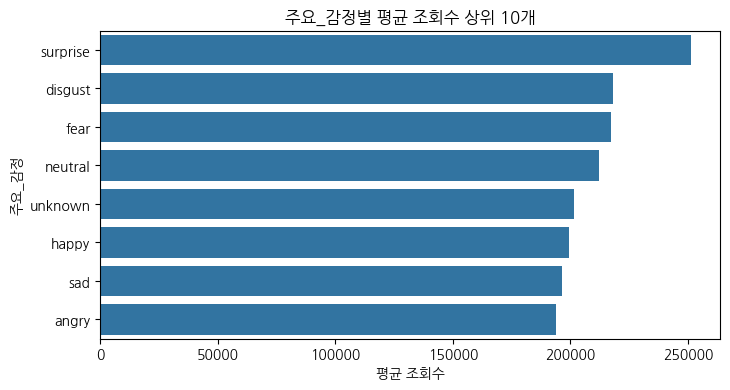


얼굴_감지여부별 평균 조회수 상위 10개
얼굴_감지여부
True     207455.496766
False    201602.722005
Name: 조회수, dtype: float64


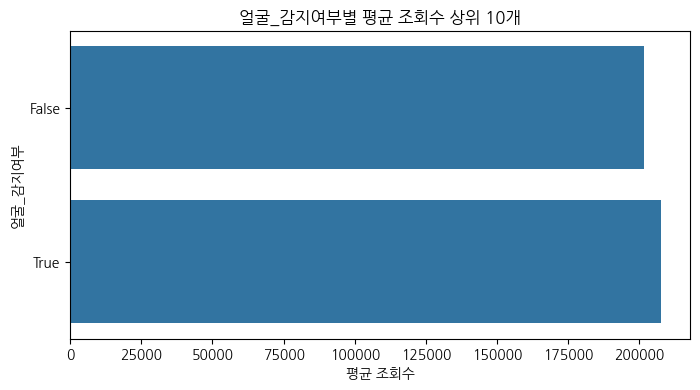


토픽키워드별 평균 조회수 상위 10개
토픽키워드
칼바람       1.064155e+06
챌린저       3.947281e+05
정글        3.514159e+05
배틀그라운드    3.314083e+05
vs        2.910219e+05
미드        2.893292e+05
발로        2.580666e+05
토픽없음      2.540418e+05
배그        2.376778e+05
2024      2.346172e+05
Name: 조회수, dtype: float64


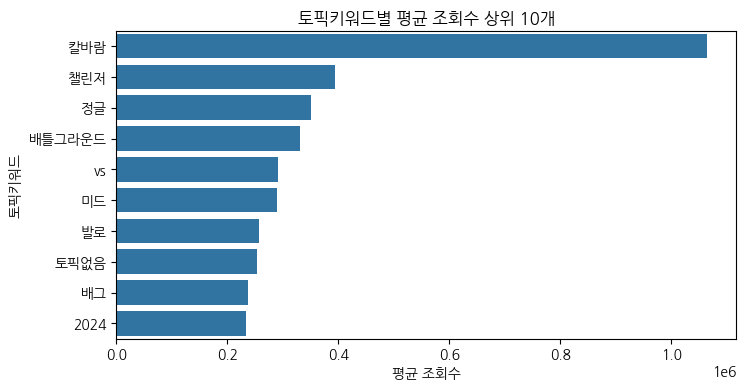


제목길이구간(사분위기반)별 평균 조회수 상위 10개
제목길이구간(사분위기반)
~21자      248721.037602
42자~      203009.760106
31~41자    192098.653816
22~30자    181011.750225
Name: 조회수, dtype: float64


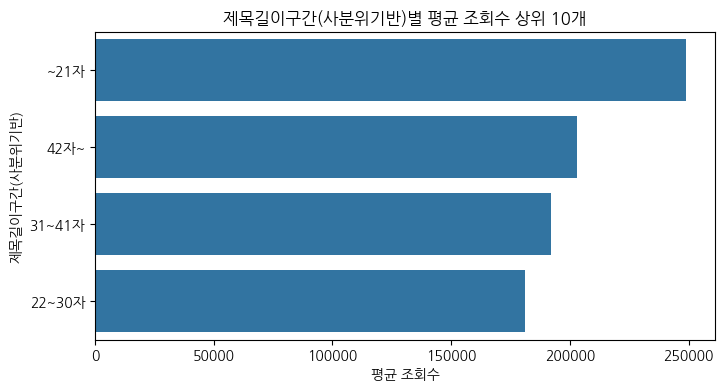

In [23]:
# 1. 한글 폰트 설치 및 적용 (코랩 전용)
# !apt-get update -qq
# !apt-get install -qq fonts-nanum
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

plt.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

# 2. 라이브러리 설치 (필요시)
!pip install optuna lightgbm scikit-learn pandas

# 3. 파일 경로 설정 및 존재 확인
import os
file_path = 'final_data_0609.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {file_path}")

# 4. 데이터 업로드 및 전처리
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(file_path, encoding='utf-8')
print("데이터 shape:", df.shape)
print("컬럼 목록:", list(df.columns))

# 제외할 컬럼
exclude_cols = ['좋아요수', '댓글수']
target = '조회수'

# 타겟 결측치 제거
df = df.dropna(subset=[target])

# 제외 컬럼 제거
cols_to_drop = [target] + [col for col in exclude_cols if col in df.columns]
X = df.drop(cols_to_drop, axis=1, errors='ignore')
y = df[target]

# 범주형 인코딩 (모든 object 컬럼)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 결측치 완전 제거
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 컬럼별 조회수 상관관계 시각화
corrs = pd.concat([X, y], axis=1).corr()[target].drop(target)
plt.figure(figsize=(10, 0.5*len(corrs)))
sns.barplot(x=corrs.values, y=corrs.index, orient='h')
plt.title('컬럼별 조회수 상관관계')
plt.xlabel('상관계수')
plt.show()

# 6. 회귀 모델별 Optuna 하이퍼파라미터 튜닝 함수 정의
import optuna
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, f1_score

def regression_objective(trial, model_name):
    if model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**params)
    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'n_jobs': -1
        }
        model = LGBMRegressor(**params)
    else:
        raise ValueError('지원하지 않는 모델')

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    return rmse

# 7. 각 모델별 Optuna 튜닝 및 결과 저장
model_names = ['RandomForest', 'LightGBM']
best_models = {}
results = []

for model_name in model_names:
    print(f"Optuna 튜닝 시작: {model_name}")
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: regression_objective(trial, model_name), n_trials=20)
    if model_name == 'RandomForest':
        model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
    elif model_name == 'LightGBM':
        model = LGBMRegressor(**study.best_params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    y_pred_bin = (preds > np.median(y_train)).astype(int)
    y_true_bin = (y_test > np.median(y_train)).astype(int)
    f1 = f1_score(y_true_bin, y_pred_bin)
    best_models[model_name] = model
    results.append({'model': model_name, 'rmse': rmse, 'r2': r2, 'f1': f1})

# 8. 모델별 성능 비교 시각화
results_df = pd.DataFrame(results)
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
sns.barplot(x='model', y='rmse', data=results_df)
plt.title('RMSE (낮을수록 좋음)')
plt.subplot(1,3,2)
sns.barplot(x='model', y='r2', data=results_df)
plt.title('R^2 (높을수록 좋음)')
plt.subplot(1,3,3)
sns.barplot(x='model', y='f1', data=results_df)
plt.title('F1-score (이진 변환)')
plt.tight_layout()
plt.show()

print(results_df)

# 9. 가장 성능 좋은 모델 및 하이퍼파라미터 출력
best_row = results_df.sort_values('rmse').iloc[0]
print(f"\n가장 성능 좋은 모델: {best_row['model']}")
print("최적 하이퍼파라미터:", best_models[best_row['model']].get_params())

# 10. 각 모델별 실제값 vs 예측값, Feature Importance 시각화
for model_name in model_names:
    model = best_models[model_name]
    preds = model.predict(X_test)

    # 실제값 vs 예측값 산점도
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test, y=preds, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
    plt.title(f'{model_name} 실제값 vs 예측값')
    plt.xlabel('실제값')
    plt.ylabel('예측값')
    plt.show()

    # Feature Importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        plt.figure(figsize=(8, 0.4*len(X.columns)))
        sns.barplot(x=importances[indices], y=X.columns[indices])
        plt.title(f'{model_name} 중요 피처(Feature Importance)')
        plt.xlabel('중요도')
        plt.show()

# 11. 컬럼별로 조회수 상승 전략 제시 (상위 20개 값 분석)
print("\n[컬럼별로 조회수 상승 전략 제시]")

# 업로드 시각(예시: '업로드_시각' 컬럼이 있을 때)
if '업로드_시각' in df.columns:
    print("\n업로드 시각별 평균 조회수 상위 10개")
    hour_mean = df.groupby('업로드_시각')[target].mean().sort_values(ascending=False).head(10)
    print(hour_mean)
    plt.figure(figsize=(8,4))
    sns.barplot(x=hour_mean.index.astype(str), y=hour_mean.values)
    plt.title('업로드 시각별 평균 조회수 상위 10개')
    plt.ylabel('평균 조회수')
    plt.xlabel('업로드 시각')
    plt.show()

# 텍스트 키워드(예시: '키워드' 컬럼이 있을 때)
if '키워드' in df.columns:
    print("\n키워드별 평균 조회수 상위 20개")
    keyword_mean = df.groupby('키워드')[target].mean().sort_values(ascending=False).head(20)
    print(keyword_mean)
    plt.figure(figsize=(10,6))
    sns.barplot(y=keyword_mean.index, x=keyword_mean.values, orient='h')
    plt.title('키워드별 평균 조회수 상위 20개')
    plt.xlabel('평균 조회수')
    plt.ylabel('키워드')
    plt.show()

# 기타 범주형 컬럼별로도 상위 10~20개 분석 (예시)
cat_cols = [col for col in df.columns if df[col].dtype == 'object' and col not in exclude_cols+[target]]
for col in cat_cols:
    print(f"\n{col}별 평균 조회수 상위 10개")
    top_mean = df.groupby(col)[target].mean().sort_values(ascending=False).head(10)
    print(top_mean)
    plt.figure(figsize=(8,4))
    sns.barplot(y=top_mean.index, x=top_mean.values, orient='h')
    plt.title(f'{col}별 평균 조회수 상위 10개')
    plt.xlabel('평균 조회수')
    plt.ylabel(col)
    plt.show()
